In [120]:
import os
import json
import requests
from datetime import datetime, timedelta, timezone
import numpy as np
import pandas as pd

# Preparing and prepping datafiles for merging
1. Annotinder files

In [121]:
file_names = [
    "annotations_95_AnnoBias job final, set 1.csv.csv",
    "annotations_96_AnnoBias job final, set 2.csv.csv",
    "annotations_97_AnnoBias job final, set 3.csv.csv",
    "annotations_98_AnnoBias job final, set 4.csv.csv",
    "annotations_99_AnnoBias job final, set 5.csv.csv",
    "annotations_100_AnnoBias job final, set 6.csv.csv"
]

dataframes = []

for idx, file in enumerate(file_names, start=1):
    df = pd.read_csv(f"data/AnnoTinder_data_exports/{file}")  
    
    # Add a "condition" column based on the file number
    df['condition_AT'] = idx    
    dataframes.append(df)  # Append the DataFrame to the list

annotinder_df = pd.concat(dataframes, ignore_index=True)
annotinder_df['uid'] = annotinder_df['coder']

2. Twitter data

In [122]:
X_data = pd.read_csv('data/X_data/final_stratified_immigration.csv')
X_data['tweet_id'] = X_data['tweet_id'].astype(str)

3. Qualtrics data 

In [123]:
# Define the cutoff date. Delete trail data from before the Soft Launch
cutoff_date = datetime(2024, 10, 14)

# Load and process the "before_before" dataset
before_before = pd.read_csv('data/Qualtrics_data_exports/start_survey.csv', skiprows=[1, 2])
#print(f"Total rows in before_before: {len(before_before)}")

# Convert StartDate to datetime and filter based on cutoff_date
before_before["time_question"] = pd.to_datetime(before_before["StartDate"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
before_before = before_before[before_before["time_question"] >= cutoff_date]

print(f"{len(before_before)} participants started the experiment")

# Load and process the "before" dataset
before = pd.read_csv('data/Qualtrics_data_exports/before.csv', skiprows=[1, 2])
#print(f"Total rows in before: {len(before)}")

before["time_question"] = pd.to_datetime(before["StartDate"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
before = before[before["time_question"] >= cutoff_date]

print(f"{len(before)} participants agreed to informed consent")

# Load and process the "after" dataset
after = pd.read_csv('data/Qualtrics_data_exports/after.csv', skiprows=[1, 2])
#print(f"Total rows in after: {len(after)}")

after["time_question"] = pd.to_datetime(after["StartDate"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
after = after[after["time_question"] >= cutoff_date]

print(f"{len(after)} continued after IAT")

2338 participants started the experiment
2163 participants agreed to informed consent
1584 continued after IAT


In [124]:
before_after = pd.merge(before, after, on='uid', how='right')
before_before['StartDate_First'] = before_before['StartDate']
qualtrics_merged = pd.merge(before_before, before_after, on='psid')

print(f"for {len(qualtrics_merged)} participants, the datasets could be merged")

# Keep only the first observation for each 'uid'
qualtrics_merged = qualtrics_merged.drop_duplicates(subset=['uid'], keep='first')

print(f"After ensuring only one observation per uid, {len(qualtrics_merged)} remain")
print(f"Unique uids after deduplication: {len(set(qualtrics_merged['uid']))}")

for 1560 participants, the datasets could be merged
After ensuring only one observation per uid, 1543 remain
Unique uids after deduplication: 1543


In [125]:
# Remove rows with missing 'dsc' values
qualtrics_merged = qualtrics_merged.dropna(subset=['dsc'])
print(f"After removing participants for whom no dsc scores could be calculated, {len(qualtrics_merged)} remain")

After removing participants for whom no dsc scores could be calculated, 1443 remain


Merge AnnoTinder and Twitter data and Qualtrics data

In [126]:
# Define the cutoff date for filtering time_question
cutoff_date = datetime(2024, 10, 14)

# Step 1: Function to handle non-numeric values and trim the first 10 digits
def trim_unit_id(unit_id):
    try:
        # Try to convert to float, then to int, and slice the first 10 characters
        return str(int(float(unit_id)))[0:10]
    except ValueError:
        # Return the original value if it's non-numeric (handle as is)
        return unit_id

# Optionally, check the unique values to confirm '50PLUS' and 'BIJ1' are no longer present
print(f"Remaining parties in 'normalized_party': {X_data['normalized_party'].unique()}")

# Step 2: Apply the trim_unit_id function to 'unit_id' in annotinder_df and 'tweet_id' in X_data
annotinder_df['unit_id_15'] = annotinder_df['unit_id'].apply(trim_unit_id)
X_data['tweet_id_15'] = X_data['tweet_id'].apply(trim_unit_id)

# Step 3: Filter X_data to include only rows with matching tweet_id_15 in annotinder_df
matching_rows = X_data[X_data['tweet_id_15'].isin(annotinder_df['unit_id_15'])]

# Step 4: Merge all columns from X_data with annotinder_df based on tweet_id_15 and unit_id_15
annotinder_twitter = annotinder_df.merge(matching_rows, 
                                         left_on='unit_id_15', right_on='tweet_id_15', 
                                         how='left')

# Step 5: Ensure 'time_question' column is converted to datetime (if necessary)
if annotinder_twitter['time_question'].dtype != 'datetime64[ns]':
    annotinder_twitter['time_question'] = pd.to_datetime(annotinder_twitter['time_question'], format="%Y-%m-%dT%H:%M:%S.%fZ")

# Step 6: Filter annotinder_twitter to only include rows where time_question >= cutoff_date
annotinder_twitter = annotinder_twitter[annotinder_twitter['time_question'] >= cutoff_date]

# Step 7: Merge with qualtrics_merged DataFrame on 'uid'
# Check if 'uid' exists in both annotinder_twitter and qualtrics_merged
if 'uid' in annotinder_twitter.columns and 'uid' in qualtrics_merged.columns:
    df = pd.merge(annotinder_twitter, qualtrics_merged, on='uid')
    print(f"After applying the cutoff date and merging, {len(df)} rows remain.")
else:
    print("Warning: 'uid' column not found in both DataFrames. Please check the column names.")

Remaining parties in 'normalized_party': ['D66' 'Volt' 'CDA' 'ChristenUnie' '50PLUS' 'Nieuw Sociaal Contract' 'SP'
 'GroenLinks' 'BIJ1' 'Partij voor de Dieren' 'PvdA' 'DENK'
 'GroenLinks-PvdA' 'PVV' 'Forum voor Democratie' 'JA21' 'VVD' 'SGP']


/tmp/ipykernel_3997897/4134590222.py:38: FutureWarning: Passing 'suffixes' which cause duplicate columns {'time_question_y'} in the result is deprecated and will raise a MergeError in a future version.
  df = pd.merge(annotinder_twitter, qualtrics_merged, on='uid')


After applying the cutoff date and merging, 156346 rows remain.


In [ ]:
#annotinder_twitter[['time_answer','text', 'source', 'uid']].head(50)

In [127]:
print(f"for {df['uid'].nunique()} participants, the AnnoTinder, qualtrics and Twitter datasets could be merged")

for 1358 participants, the AnnoTinder, qualtrics and Twitter datasets could be merged


In [128]:
# Check and remove tweets from BIJ1 and 50PLUS as we do not have measurements for these parties:
print(f"Number of Annotations from BIJ1: {len(df[df['normalized_party'] == 'BIJ1'])}")
print(f"Number of Annotations from 50PLUS: {len(df[df['normalized_party'] == '50PLUS'])}")

Number of Annotations from BIJ1: 1632
Number of Annotations from 50PLUS: 1040


In [129]:
## Removing anntoations from BIj1 and 50plus:

# Remove rows from df where normalized_party is 'BIJ1' or '50PLUS'
print(f"Size of the dataset before removal: {len(df)}")

# Filter out rows with normalized_party as 'BIJ1' or '50PLUS'
df = df[~df['normalized_party'].isin(['BIJ1', '50PLUS'])]

print(f"Size of the dataset after removal: {len(df)}")

Size of the dataset before removal: 156346
Size of the dataset after removal: 153674


In [130]:
# Function to calculate time differences
def calculate_time_differences_fixed_mdt(start_dates, time_answers):
    differences = []
    
    for start, answer in zip(start_dates, time_answers):
        # Ensure both start and answer are valid
        if pd.isnull(start) or pd.isnull(answer):
            differences.append(None)  # Missing data
            continue
        
        try:
            # Parse StartDate_First (MDT: UTC-6)
            start_dt = datetime.strptime(str(start), '%Y-%m-%d %H:%M:%S')
            start_dt_utc = (start_dt + timedelta(hours=6)).replace(tzinfo=timezone.utc)
            
            # Parse time_answer (UTC)
            answer_dt = datetime.strptime(str(answer), '%Y-%m-%dT%H:%M:%S.%fZ').replace(tzinfo=timezone.utc)
            
            # Calculate time difference in minutes
            time_diff = (answer_dt - start_dt_utc).total_seconds() / 60
            differences.append(time_diff)
        except Exception as e:
            print(f"Error processing row: {start}, {answer} - {e}")
            differences.append(None)
    
    return differences

# Calculate time differences
time_differences = calculate_time_differences_fixed_mdt(df['StartDate_First'], df['time_answer'])

# Add time_difference column to DataFrame
df['time_difference'] = time_differences

# Sort and get the last observation for each psid
df = df.sort_values(by=['psid', 'time_answer'])
last_observation = df.groupby('psid').last().reset_index()


In [131]:
df.tail(5)

,coder_id,coder,jobset,unit_id,unit_status,variable,value,time_question_x,time_answer,field,...,Q6_Page Submit,Q6_Click Count,sid_y,project_y,dsc,dst,Condition,IP_Address_y,time_question_y,time_difference
108111,14129,266261,batch_29,1751994181583606016,DONE,stellingen.misinformation,Neutraal,2024-10-15 09:30:32.109,2024-10-15T09:30:45.238Z,NaN,...,NaN,NaN,8554_5150,IAT_2024,0.51324,1.0,5,31.20.84.125,2024-10-15 03:27:43,10.553967
108112,14129,266261,batch_29,1369999670588624896,DONE,stellingen.political_stance,Gedeeltelijk waar,2024-10-15 09:30:46.666,2024-10-15T09:30:47.295Z,NaN,...,NaN,NaN,8554_5150,IAT_2024,0.51324,1.0,5,31.20.84.125,2024-10-15 03:27:43,10.588250
108113,14129,266261,batch_29,1369999670588624896,DONE,stellingen.sentiment,Gedeeltelijk niet waar,2024-10-15 09:30:46.666,2024-10-15T09:30:47.429Z,NaN,...,NaN,NaN,8554_5150,IAT_2024,0.51324,1.0,5,31.20.84.125,2024-10-15 03:27:43,10.590483
108114,14129,266261,batch_29,1369999670588624896,DONE,stellingen.toxic,Gedeeltelijk waar,2024-10-15 09:30:46.666,2024-10-15T09:30:47.580Z,NaN,...,NaN,NaN,8554_5150,IAT_2024,0.51324,1.0,5,31.20.84.125,2024-10-15 03:27:43,10.593000
108115,14129,266261,batch_29,1369999670588624896,DONE,stellingen.misinformation,Neutraal,2024-10-15 09:30:46.666,2024-10-15T09:30:47.810Z,NaN,...,NaN,NaN,8554_5150,IAT_2024,0.51324,1.0,5,31.20.84.125,2024-10-15 03:27:43,10.596833


## Compute variables

In [132]:
df['uid'].nunique()

1358

In [ ]:
''''

## Remove participants who either did not complete the coding job or did multiple rounds 
df['uid'].value_counts()

uid_counts = df['uid'].value_counts()
# Filter for those uids that have exactly 131 observations
uids_with_131 = uid_counts[uid_counts == 131].index

# Filter the original DataFrame to keep only those uids
df = df[df['uid'].isin(uids_with_131)]

print(f"After removing participants who either did not complete the coding job or did multiple rounds, {len(set(df['uid']))} remain")

In [133]:
pd.crosstab(df['condition_AT'], df['Condition'])

Condition,1,2,3,4,5,6
condition_AT,,,,,,
1,25303,0,0,0,0,0
2,0,27211,0,0,0,0
3,0,0,25150,0,0,0
4,0,0,0,25593,0,0
5,0,0,0,0,25100,0
6,0,0,0,0,0,25317


In [134]:
df['uid'].nunique()
df['uid'].nunique()
df[['uid', 'jobset']].nunique()

uid       1358
jobset      62
dtype: int64

In [135]:
print(df['normalized_party'].unique())

[nan 'SP' 'GroenLinks' 'Partij voor de Dieren' 'PvdA' 'DENK'
 'GroenLinks-PvdA' 'VVD' 'PVV' 'Forum voor Democratie' 'JA21' 'Volt' 'D66'
 'CDA' 'ChristenUnie' 'Nieuw Sociaal Contract' 'SGP']


In [136]:

# Sample likert_mapping (you have already defined this)
likert_mapping = {
    "Geheel onwaarschijnlijk": 1,
    "Onwaarschijnlijk": 2,
    "Niet waarschijnlijk, maar ook niet onwaarschijnlijk": 3,
    "Waarschijnlijk": 4,
    "Zeer waarschijnlijk": 5
}

# Assuming df is your DataFrame containing individual data

# Step 1: Map Likert responses to numeric values for each party
party_columns = ['PolCongr_1', 'PolCongr_2', 'PolCongr_3', 'PolCongr_4', 'PolCongr_5', 
                 'PolCongr_6', 'PolCongr_7', 'PolCongr_8', 'PolCongr_9', 'PolCongr_10',
                 'PolCongr_11', 'PolCongr_12', 'PolCongr_13', 'PolCongr_14', 'PolCongr_15']

# Map Likert scale responses to numeric values for all relevant columns
for party in party_columns:
    df[party] = df[party].map(likert_mapping)

# Step 2: Create a mapping from party names to their corresponding PolCongr_* columns
party_to_column_mapping = {
    'PVV': 'PolCongr_1',
    'GroenLinks-PvdA': 'PolCongr_2',  # GL-PvdA combined
    'VVD': 'PolCongr_3',
    'Nieuw Sociaal Contract': 'PolCongr_4',
    'D66': 'PolCongr_5',
    'BBB': 'PolCongr_6',
    'CDA': 'PolCongr_7',
    'SP': 'PolCongr_8',
    'DENK': 'PolCongr_9',
    'Partij voor de Dieren': 'PolCongr_10',
    'Forum voor Democratie': 'PolCongr_11',
    'SGP': 'PolCongr_12',
    'ChristenUnie': 'PolCongr_13',
    'Volt': 'PolCongr_14',
    'JA21': 'PolCongr_15'
}


# Step 3: Combine the relevant parties ('GroenLinks', 'PvdA', 'GroenLinks-PvdA') into a single group
df['normalized_party'] = df['normalized_party'].replace({
    'GroenLinks': 'GroenLinks-PvdA',  # Combine GroenLinks and PvdA into GroenLinks-PvdA
    'PvdA': 'GroenLinks-PvdA'
})


# Step 4: Calculate the score for the normalized party (single numeric score)

def calculate_party_score(row):
    normalized_party = row['normalized_party']
    
    # Look up the column corresponding to the normalized party
    normalized_party_column = party_to_column_mapping.get(normalized_party)
    
    if normalized_party_column:
        # Return the score from the corresponding column for the normalized party
        return row[normalized_party_column]
    else:
        return None

# Step 6: Apply the function to calculate the score for each participant
df['vote_likelihood_score'] = df.apply(calculate_party_score, axis=1)

# Step 7: Check the updated DataFrame with the vote likelihood score
#df[['normalized_party', 'vote_likelihood_score']].tail(50)
df['vote_likelihood_score'].value_counts()

df[['normalized_party', 'vote_likelihood_score']].tail(3)

,normalized_party,vote_likelihood_score
108113,SP,2.0
108114,SP,2.0
108115,SP,2.0


In [137]:
# Define the mapping for instructions
instruction_mapping = {
    1: "no instructions",
    2: "general instructions",
    3: "tailored instructions",
    4: "no instructions",
    5: "general instructions",
    6: "tailored instructions",
}

# Convert condition to integers before mapping
df["instruction_type"] = df["Condition"].astype(int).map(instruction_mapping)

# Define whether the condition includes author handle
df["source_shown"] = df["Condition"].astype(int).apply(lambda x: 0 if x in [1, 2, 3] else 1)


# Assuming df['Age_y'] contains the year of birth
current_year = datetime.now().year

# Create the 'Age' column by subtracting the year of birth from the current year
df['Age'] = current_year - df['Age_y']
df['Male'] = df['gender'].map({'male': 1, 'female': 0, 'other/unknown': 0})

In [138]:
df['instruction_type'].value_counts()
df['source_shown'].value_counts()

0    77664
1    76010
Name: source_shown, dtype: int64

In [139]:
df['Ideology']
df['text']

120233                                                  NaN
120234                                                  NaN
120235                                                  NaN
120236                                                  NaN
120237                                                  NaN
                                ...                        
108111    Stop het hapsnapbeleid bij de opvang van asiel...
108112    Onze initiatiefwet Verdringingstoets is in de ...
108113    Onze initiatiefwet Verdringingstoets is in de ...
108114    Onze initiatiefwet Verdringingstoets is in de ...
108115    Onze initiatiefwet Verdringingstoets is in de ...
Name: text, Length: 153674, dtype: object

In [140]:
df[df['variable'] == 'stellingen.political_stance'][['Ideology', 'normalized_party','PolOrient_1']]

,Ideology,normalized_party,PolOrient_1
120244,-2.0,SP,4.0
120248,-3.0,GroenLinks-PvdA,4.0
120252,-3.0,GroenLinks-PvdA,4.0
120256,-3.0,GroenLinks-PvdA,4.0
120260,-3.0,GroenLinks-PvdA,4.0
...,...,...,...
108092,-3.0,GroenLinks-PvdA,9.0
108096,-2.0,SP,9.0
108104,-3.0,GroenLinks-PvdA,9.0
108108,-3.0,GroenLinks-PvdA,9.0


In [141]:
df[df['variable'] == 'stellingen.political_stance'][['Ideology', 'normalized_party','PolOrient_1']]

df['instruction_type'].value_counts()
df['source_shown'].value_counts()

0    77664
1    76010
Name: source_shown, dtype: int64

In [142]:
df['variable'].value_counts()

stellingen.misinformation      34811
stellingen.political_stance    34809
stellingen.toxic               34809
stellingen.sentiment           34808
confirm                         3980
political_stance_training       2642
sentiment_training              2618
toxic_training                  2603
misinformation_training         2594
Name: variable, dtype: int64

In [ ]:
#list(df)
#df_clean = df.reset_index(drop=True)
#df_clean = df.dropna(subset=['value_scaled', 'vote_likelihood_score', 'PolOrient_1', 'source_shown', 'dsc', 'coder_id', 'tweet_id'])
#df_clean

In [143]:
# Encode the stance as an ordinal variable
scale_mapping = {
    "Helemaal niet waar": 1,
    "Gedeeltelijk niet waar": 2,
    "Neutraal": 3,
    "Gedeeltelijk waar": 4,
    "Helemaal waar": 5
}

df['value_nan'] = df['value'].replace(['Waar', 'Niet waar', 'confirmed'], np.nan)

# Map the remaining categories to a numeric scale
df['value_scaled'] = df['value_nan'].map(scale_mapping)
# Check the updated DataFrame
print(df[['value', 'value_scaled']].tail())

                         value  value_scaled
108111                Neutraal           3.0
108112       Gedeeltelijk waar           4.0
108113  Gedeeltelijk niet waar           2.0
108114       Gedeeltelijk waar           4.0
108115                Neutraal           3.0


In [144]:
# Check for missing values in key columns
df[df['variable'] == 'stellingen.toxic'][['vote_likelihood_score', 'source_shown', 'dsc', 'instruction_type', 'value_scaled']].isna().sum()

vote_likelihood_score    0
source_shown             0
dsc                      0
instruction_type         0
value_scaled             0
dtype: int64

In [ ]:
df['variable'].value_counts()

In [147]:
import statsmodels.formula.api as smf

# Fit the model
model = smf.mixedlm(
    "value_scaled ~vote_likelihood_score * instruction_type + source_shown + dsc ",
    data=df[df['variable'] == 'stellingen.toxic'],
    groups="uid",  # Grouping variable
    re_formula="~1"
)

# Fit the model and summarize the results
result = model.fit()
print(result.summary())

                                  Mixed Linear Model Regression Results
Model:                            MixedLM                 Dependent Variable:                 value_scaled
No. Observations:                 34809                   Method:                             REML        
No. Groups:                       1248                    Scale:                              1.0543      
Min. group size:                  1                       Log-Likelihood:                     -52132.7147 
Max. group size:                  30                      Converged:                          Yes         
Mean group size:                  27.9                                                                    
----------------------------------------------------------------------------------------------------------
                                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Define the subsets of interest
variables_of_interest = [
    'stellingen.misinformation',
    'stellingen.toxic',
    'stellingen.sentiment'
]

# Initialize a list to store the results
for variable in variables_of_interest:
    subset_df = df[df['variable'] == variable]

    model = smf.mixedlm(
        "value_scaled ~ vote_likelihood_score + source_shown + dsc + instruction_type",
        data=subset_df,
        groups=subset_df["uid"],
        re_formula="~1"
    )
    result = model.fit()

    coefs = result.params
    conf_int = result.conf_int()

    model_results = pd.DataFrame({
        'Coefficient': coefs.index,
        'Estimate': coefs.values,
        'CI Lower': conf_int[0],
        'CI Upper': conf_int[1],
        'Model': variable
    })

    results.append(model_results)

results_df = pd.concat(results)

# Plotting
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")

sns.pointplot(
    data=results_df,
    x="Estimate",
    y="Coefficient",
    hue="Model",
    dodge=True,
    join=False,
    palette="tab10",
    scale=0.5
)

for i, row in results_df.iterrows():
    plt.errorbar(
        x=row["Estimate"],
        y=row["Coefficient"],
        xerr=[[row["Estimate"] - row["CI Lower"]], [row["CI Upper"] - row["Estimate"]]],
        fmt='none',
        c="gray",
        capsize=4
    )

plt.title("Model Coefficients Across Data Subsets")
plt.xlabel("Coefficient Estimate")
plt.ylabel("Predictor")
plt.tight_layout()
plt.legend(title="Model", loc="upper left")
plt.show()

In [153]:

# Convert 'tweet_id' to string
df['tweet_id_str'] = df['tweet_id'].astype(str)

# Save as CSV with proper quoting
df.to_csv("datafile_cleaned.csv", index=False, quoting=1)

# Save as Parquet (recommended for preserving data types)
df.to_parquet("datafile_cleaned.parquet", index=False)

# Save as Pickle (alternative option)
df.to_pickle("datafile_cleaned.pkl")
df.to_csv("datafile.csv")

ValueError: Duplicate column names found: ['coder_id', 'coder', 'jobset', 'unit_id', 'unit_status', 'variable', 'value', 'time_question_x', 'time_answer', 'field', 'condition_AT', 'uid', 'unit_id_15', 'Unnamed: 0', 'Unnamed: 0_x', 'tweet_id', 'timestamp', 'text', 'full_text', 'hashtags', 'urls', 'source', 'Author', 'is_duplicated', 'twitter_username', 'Unnamed: 0_y', 'Name', 'Party', 'Start Date', 'End Date', 'Wikidata_ID', 'gender', 'birthday', 'twitter_numeric_user_id', 'subscriber_count', 'start_date', 'point_in_time', 'period', 'Location', 'Age_x', 'Seniority', 'Image_URL', 'Political_Party', 'normalized_party', 'Ideology', 'Ideology_Group', 'immigration', 'tweet_id_15', 'StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'ExternalReference', 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage', 'Q2', 'psid', 'IP_Address_x'

In [27]:

import pandas as pd
import statsmodels.formula.api as smf

# Step 1: Fit Stepwise Mixed-Effects Models
def fit_stepwise_models(data, variable_name):
    """
    Fits stepwise mixed-effects models for a given dependent variable.

    Args:
        data (pd.DataFrame): The dataset containing the variables.
        variable_name (str): The dependent variable to analyze.

    Returns:
        list: A list of fitted mixed-effects models (MixedLMResults objects).
    """
    # Filter data for the specific variable
    filtered_data = data[data['variable'] == variable_name]
    
    # Define stepwise formulas
    formulas = [
        "value_scaled ~ Male + Age + source_shown + instruction_type",  # Step 1: Base model
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score",  # Step 2: Add instruction_type as categorical
        "value_scaled ~ Male + Age + source_shown + instruction_type + vote_likelihood_score + dsc",  # Step 3: Add vote_likelihood_score and dsc
        "value_scaled ~ Male + Age + source_shown * vote_likelihood_score + instruction_type + dsc",  # Step 4: Add interaction term
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * dsc + instruction_type",  # Step 5: New formula 1
        "value_scaled ~ Male + Age + source_shown + vote_likelihood_score * instruction_type + dsc"  # Step 6: New formula 2
    ]
    
    # Fit models and store results
    models = []
    for formula in formulas:
        model = smf.mixedlm(
            formula=formula,
            data=filtered_data,
            groups=filtered_data["uid"]  # Grouping variable
        ).fit()
        models.append(model)
    
    return models
def generate_clean_latex_table_with_group_var(variable_name, model_results, decimals=2):
    """
    Generates a clean LaTeX table for a specific variable's stepwise model results, 
    including Group Var, ICC, N (obs), and N (groups) per model.

    Args:
        variable_name (str): The name of the dependent variable.
        model_results (list): List of fitted mixed-effects models (statsmodels MixedLMResults objects).
        decimals (int): Number of decimal places to round numerical values.

    Returns:
        str: A LaTeX table as a string.
    """
    # Prepare a DataFrame to hold results
    result_df = pd.DataFrame(columns=['Predictor', 'B (Model 1)', 'B (Model 2)', 'B (Model 3)', 'B (Model 4)', 'B (Model 5)', 'B (Model 6)'])

    # List of predictors to include in the table
    predictors = [
        'Intercept', 
        'source_shown', 
        'instruction_type[T.no instructions]', 
        'instruction_type[T.tailored instructions]', 
        'vote_likelihood_score', 
        'dsc', 
        'source_shown:vote_likelihood_score', 
        'vote_likelihood_score:dsc', 
        'vote_likelihood_score:instruction_type[T.no instructions]', 
        'vote_likelihood_score:instruction_type[T.tailored instructions]', 
        'Male',
        'Age',
    ]

    # Extract results for each predictor from each model
    for predictor in predictors:
        row = {'Predictor': predictor}
        for i, model in enumerate(model_results):
            if predictor in model.params.index:
                b_value = model.params[predictor]
                se_value = model.bse[predictor]
                significance_star = ""
                p_value = model.pvalues[predictor]
                if p_value < 0.001:
                    significance_star = "***"
                elif p_value < 0.01:
                    significance_star = "**"
                elif p_value < 0.05:
                    significance_star = "*"
                row[f'B (Model {i+1})'] = f"{b_value:.{decimals}f} ({se_value:.{decimals}f}){significance_star}"
            else:
                row[f'B (Model {i+1})'] = ""
        result_df = pd.concat([result_df, pd.DataFrame([row])], ignore_index=True)

    # Add ICC as a separate row
    for metric_name in ['ICC']:
        row = {'Predictor': metric_name}
        for i, model in enumerate(model_results):
            if metric_name == 'ICC':
                group_var = model.cov_re.iloc[0, 0] if not model.cov_re.empty else float('nan')
                residual_var = model.scale
                icc = group_var / (group_var + residual_var) if group_var + residual_var > 0 else float('nan')
                row[f'B (Model {i+1})'] = f"{icc:.{decimals}f}"
        result_df = pd.concat([result_df, pd.DataFrame([row])], ignore_index=True)

    # Add Log-Likelihood as a separate row
    log_likelihood_row = {'Predictor': 'Log-Likelihood'}
    for i, model in enumerate(model_results):
        log_likelihood_row[f'B (Model {i+1})'] = f"{model.llf:.{decimals}f}"
    result_df = pd.concat([result_df, pd.DataFrame([log_likelihood_row])], ignore_index=True)

    # Add N (obs) and N (groups) for each model (Do not repeat Group Var and Residual Var)
    summary_rows = {
        'Predictor': ['N (Obs)', 'N (Groups)'],
    }

    for i, model in enumerate(model_results):
        # N (Obs): Number of observations
        n_obs = int(model.nobs)
        # N (Groups): Number of groups (using group_labels or similar)
        try:
            n_groups = len(model.model.group_labels)  # Number of groups from group_labels
        except AttributeError:
            n_groups = len(model.random_effects)  # Fallback: number of random effect levels

        # Add summary for the model
        summary_rows[f"B (Model {i+1})"] = [
            n_obs,
            n_groups
        ]

    # Create DataFrame for summary rows and append to result_df
    summary_df = pd.DataFrame(summary_rows)
    result_df = pd.concat([result_df, summary_df], ignore_index=True)

    # Generate LaTeX table
    latex_table = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{Stepwise Mixed-Effects Model Results for {variable_name}}}\n"
        f"\\label{{tab:{variable_name}}}\n"
        "\\resizebox{\\textwidth}{!}{%\n"
        + result_df.to_latex(
            index=False,
            escape=True,
            na_rep=""  # Replace NaN with truly empty cells
        )
        + "}\n\\end{table}"
    )
    
    return latex_table



In [28]:
# List of variables to analyze
variables = ['stellingen.misinformation', 'stellingen.toxic', 'stellingen.sentiment']

# Dictionary to store fitted models for each variable
fitted_models = {}

# Fit models and generate LaTeX tables for each variable
latex_tables_clean = {}
for var in variables:
    try:
        print(f"Fitting models for variable: {var}")
        # Fit stepwise models for this variable
        fitted_models[var] = fit_stepwise_models(df, var)

        print(f"Generating LaTeX table for variable: {var}")
        # Generate LaTeX table for this variable using fitted models
        latex_tables_clean[var] = generate_clean_latex_table_with_group_var(var, fitted_models[var])

        # Check if LaTeX table generation returned None
        if latex_tables_clean[var] is None:
            raise ValueError(f"LaTeX table for variable {var} is None.")
    except Exception as e:
        print(f"Error processing variable {var}: {e}")
        latex_tables_clean[var] = None  # Set None to indicate failure

# Save LaTeX Tables to Files
for var, latex_table in latex_tables_clean.items():
    if latex_table is not None:
        with open(f"{var}_table.tex", "w") as f:
            f.write(latex_table)
    else:
        print(f"Skipping saving LaTeX table for variable {var} due to errors.")

# Print tables to console for verification (optional)
for var, latex_table in latex_tables_clean.items():
   print(f"\nLaTeX Table for {var}:\n")
   print(latex_table)

Fitting models for variable: stellingen.misinformation
Generating LaTeX table for variable: stellingen.misinformation


/tmp/ipykernel_3988626/1330890060.py:140: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  + result_df.to_latex(


Fitting models for variable: stellingen.toxic
Generating LaTeX table for variable: stellingen.toxic


/tmp/ipykernel_3988626/1330890060.py:140: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  + result_df.to_latex(


Fitting models for variable: stellingen.sentiment
Generating LaTeX table for variable: stellingen.sentiment

LaTeX Table for stellingen.misinformation:

\begin{table}[ht]
\centering
\caption{Stepwise Mixed-Effects Model Results for stellingen.misinformation}
\label{tab:stellingen.misinformation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lllllll}
\toprule
                                         Predictor &    B (Model 1) &     B (Model 2) &     B (Model 3) &     B (Model 4) &     B (Model 5) &     B (Model 6) \\
\midrule
                                         Intercept & 2.77 (0.09)*** &  2.95 (0.09)*** &  2.97 (0.09)*** &  2.87 (0.09)*** &  2.94 (0.09)*** &  2.90 (0.09)*** \\
                                      source\_shown &    0.00 (0.04) &     0.01 (0.04) &     0.02 (0.04) &  0.22 (0.05)*** &     0.02 (0.04) &     0.01 (0.04) \\
               instruction\_type[T.no instructions] &   -0.03 (0.05) &    -0.03 (0.05) &    -0.03 (0.05) &    -0.04 (0.05) &    -0.03 (0.05) &     0

/tmp/ipykernel_3988626/1330890060.py:140: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  + result_df.to_latex(


In [24]:
df[['value_scaled', 'variable', 'Male', 'Age', 'vote_likelihood_score', 'dsc', 'source_shown', 'instruction_type', 'Ideology_Group', 'tweet_id', 'uid', 'normalized_party']].describe(include='all')

,value_scaled,variable,Male,Age,vote_likelihood_score,dsc,source_shown,instruction_type,Ideology_Group,tweet_id,uid,normalized_party
count,139268.000000,153674,139237.000000,153674.000000,139237.000000,153674.000000,153674.000000,153674,139237,139237,153674.000000,139237
unique,NaN,9,NaN,NaN,NaN,NaN,NaN,3,3,1826,NaN,14
top,NaN,stellingen.misinformation,NaN,NaN,NaN,NaN,NaN,general instructions,Center,1494400544953311234,NaN,GroenLinks-PvdA
freq,NaN,34811,NaN,NaN,NaN,NaN,NaN,52311,48280,104,NaN,31381
mean,2.841284,NaN,0.618191,50.454944,2.156180,0.501095,0.494618,NaN,NaN,NaN,267112.123372,NaN
std,1.334109,NaN,0.485832,15.575923,1.264588,0.451990,0.499973,NaN,NaN,NaN,688.357764,NaN
min,1.000000,NaN,0.000000,25.000000,1.000000,-1.288011,0.000000,NaN,NaN,NaN,265991.000000,NaN
25%,2.000000,NaN,0.000000,37.000000,1.000000,0.220348,0.000000,NaN,NaN,NaN,266500.000000,NaN
50%,3.000000,NaN,1.000000,51.000000,2.000000,0.546482,0.000000,NaN,NaN,NaN,267103.000000,NaN
75%,4.000000,NaN,1.000000,64.000000,3.000000,0.837775,1.000000,NaN,NaN,NaN,267669.000000,NaN


In [4]:
!pip3 install fastparquet

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.6 MB/s eta 0:00:00


## Modelling Similarity

In [116]:
import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
import krippendorff
import statsmodels.api as sm
import statsmodels.formula.api as smf

df =pd.read_csv("datafile.csv")
print(len(df))

/tmp/ipykernel_3997897/3232995315.py:9: DtypeWarning: Columns (95,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df =pd.read_csv("datafile.csv")


153674


In [154]:
df_copy = df

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm
import gc
import os

# Filter Data
print("Initial dataset size:", df.shape)
df_filtered = df[df['variable'] == 'stellingen.misinformation']
print("After filtering by 'variable', dataset size:", df_filtered.shape)

# Convert `tweet_id` to string
df_filtered['tweet_id'] = df_filtered['tweet_id'].apply(lambda x: f"{int(x):.0f}")
print("Unique tweet_ids after conversion:", df_filtered['tweet_id'].nunique())

# Reduce memory usage
df_filtered = df_filtered[['value_scaled', 'tweet_id', 'uid', 'Age', 'Male',  'source_shown', 'instruction_type', 'dsc', 'vote_likelihood_score', 'PolOrient_1', 'ImportIssue_1', 'normalized_party', 'Ideology_Group']]
#print("Dataset size after selecting columns:", df_filtered.shape)

# Ensure `tweet_id`s have at least two annotators
annotations = df_filtered[['value_scaled', 'tweet_id', 'uid', 'normalized_party', 'Ideology_Group']]
annotations_pivot = annotations.pivot_table(index=['tweet_id', 'normalized_party', 'Ideology_Group'], 
                                            columns='uid', 
                                            values='value_scaled', 
                                            aggfunc='first')

# Drop `tweet_id`s with fewer than two annotators
print("Unique tweet_ids before filtering for annotators:", annotations_pivot.index.nunique())
annotations_pivot = annotations_pivot.dropna(thresh=2)
print("Unique tweet_ids with at least two annotators:", annotations_pivot.index.nunique())

# Ensure all column names are strings in annotations_pivot
annotations_pivot.columns = annotations_pivot.columns.map(str)
annotations_pivot.reset_index(inplace=True)

# Save intermediate results for inspection
annotations_pivot.to_parquet("annotations_pivot_debug.parquet", engine="fastparquet")
print("Saved annotations_pivot_debug.parquet successfully.")

annotations_pivot.to_parquet("annotations_pivot_debug.parquet", engine="fastparquet")

if annotations_pivot.shape[0] == 0:
    raise ValueError("No tweet_ids have at least two annotators. Please check the input data.")

# Save unique user attributes
unique_uids = df_filtered[['uid', 'Age', 'Male', 'dsc', 'vote_likelihood_score',  'source_shown', 'instruction_type','PolOrient_1', 'ImportIssue_1']].drop_duplicates('uid')
unique_uids['uid'] = unique_uids['uid'].astype(str)

print("Unique users (uids):", unique_uids['uid'].nunique())
unique_uids.to_parquet("unique_uids_debug.parquet", engine="fastparquet")

# Pairwise Differences Calculation
def calculate_pairwise_differences_with_tweet_ids(annotations_pivot_path, unique_uids_path, output_path):
    annotations_pivot = pd.read_parquet(annotations_pivot_path)
    unique_uids = pd.read_parquet(unique_uids_path)

    annotations_pivot.reset_index(inplace=True)
    results = []

    print("Starting pairwise differences calculation...")
    for _, row in tqdm(annotations_pivot.iterrows(), desc="Processing tweet_ids", total=len(annotations_pivot)):
        tweet_id = row['tweet_id']

        normalized_party = row['normalized_party']
        Ideology_Group = row['Ideology_Group']

        annotators = row.drop('tweet_id').dropna().index.tolist()

        if len(annotators) < 2:
            print(f"Skipped tweet_id {tweet_id}: Less than two annotators.")
            continue

        for uid_1, uid_2 in combinations(annotators, 2):
            try:
                annotator_1 = unique_uids[unique_uids['uid'] == uid_1]
                annotator_2 = unique_uids[unique_uids['uid'] == uid_2]

                if annotator_1.empty or annotator_2.empty:
                    #print(f"Missing annotator data for tweet_id {tweet_id}, uid_1: {uid_1}, uid_2: {uid_2}")
                    continue

                annotator_1 = annotator_1.iloc[0]
                annotator_2 = annotator_2.iloc[0]
                
                both_saw_source = annotator_1["source_shown"] == annotator_2["source_shown"]
                similar_instructions = annotator_1["instruction_type"] == annotator_2["instruction_type"]


                results.append({
                    'tweet_id': tweet_id,
                    'normalized_party' : normalized_party ,
                    'Ideology_Group' : Ideology_Group,
                    
                    'uid_1': uid_1,
                    'uid_2': uid_2,
                    'age_diff': abs(annotator_1['Age'] - annotator_2['Age']),
                    'gender_diff': abs(annotator_1['Male'] - annotator_2['Male']),
                    'dsc_diff': abs(annotator_1['dsc'] - annotator_2['dsc']),
                    'vote_likelihood_diff': abs(annotator_1['vote_likelihood_score'] - annotator_2['vote_likelihood_score']),
                    'Age_annotator_1': annotator_1['Age'],
                    'Male_annotator_1': annotator_1['Male'],
                     'Age_annotator_2': annotator_2['Age'],
                    'Male_annotator_2': annotator_2['Male'],
                    'dsc_annotator_1': annotator_1['dsc'],
                     'dsc_annotator_2': annotator_2['dsc'],
                    'vote_likelihood_annotator_1': annotator_1['vote_likelihood_score'],
                    'vote_likelihood_annotator_2': annotator_2['vote_likelihood_score'],
                    'ImportIssue_annotator_1': annotator_1['ImportIssue_1'],
                    'source_shown_annotator_1': annotator_1['source_shown'],
                    'instruction_type_annotator_1': annotator_1['instruction_type'],
                    'PolOrient_annotator_1': annotator_1['PolOrient_1'] ,
                     "both_saw_source": both_saw_source,  # True if both saw the source
                     "similar_instructions": similar_instructions,
                  # True if instructions were similar
              
                    
                })
            except Exception as e:
                print(f"Error processing tweet_id {tweet_id}, uid_1: {uid_1}, uid_2: {uid_2}. Error: {e}")

        # Save periodically
        if len(results) >= 10000:
            if os.path.exists(output_path):
                pd.DataFrame(results).to_parquet(output_path, engine="fastparquet", index=False, append=True)
            else:
                pd.DataFrame(results).to_parquet(output_path, engine="fastparquet", index=False)
            results = []

    # Save remaining results
    if results:
        if os.path.exists(output_path):
            pd.DataFrame(results).to_parquet(output_path, engine="fastparquet", index=False, append=True)
        else:
            pd.DataFrame(results).to_parquet(output_path, engine="fastparquet", index=False)

    print("Pairwise differences calculation completed.")

calculate_pairwise_differences_with_tweet_ids(
    annotations_pivot_path="annotations_pivot_debug.parquet",
    unique_uids_path="unique_uids_debug.parquet",
    output_path="pairwise_results_with_tweet_ids_debug.parquet"
)

Initial dataset size: (153674, 186)
After filtering by 'variable', dataset size: (34811, 186)
Unique tweet_ids after conversion: 1826
Unique tweet_ids before filtering for annotators: 1826


/tmp/ipykernel_3997897/4056742862.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Unique tweet_ids with at least two annotators: 1826
Saved annotations_pivot_debug.parquet successfully.
Unique users (uids): 1248
Starting pairwise differences calculation...


Processing tweet_ids:  61%|██████    | 1107/1826 [02:33<01:50,  6.50it/s]

In [298]:
import pandas as pd

# Load the datasets to check the unique count of tweet_ids
pairwise_path = "pairwise_results_with_tweet_ids_debug.parquet"
annotations_path = "annotations_pivot_debug.parquet"

# Read the pairwise results and annotations data
pairwise_data = pd.read_parquet(pairwise_path)
annotations_data = pd.read_parquet(annotations_path)

# Get unique count of tweet_ids in both datasets
pairwise_unique_tweets = pairwise_data['tweet_id'].nunique()
annotations_unique_tweets = annotations_data['tweet_id'].nunique()

print(pairwise_unique_tweets)
print(annotations_unique_tweets)
# Check for `tweet_id` mismatch
annotations_tweet_ids = set(annotations_data['tweet_id'])
pairwise_tweet_ids = set(pairwise_data['tweet_id'])

# Calculate differences
missing_in_pairwise = annotations_tweet_ids - pairwise_tweet_ids
missing_in_annotations = pairwise_tweet_ids - annotations_tweet_ids

print(f"Tweet IDs in annotations but missing in pairwise: {len(missing_in_pairwise)}")
print(f"Tweet IDs in pairwise but missing in annotations: {len(missing_in_annotations)}")

# Check for duplicates in both datasets
print(f"Duplicates in pairwise data: {pairwise_data.duplicated(subset='tweet_id').sum()}")
print(f"Duplicates in annotations data: {annotations_data.duplicated(subset='tweet_id').sum()}")

1826
1826
Tweet IDs in annotations but missing in pairwise: 0
Tweet IDs in pairwise but missing in annotations: 0
Duplicates in pairwise data: 317287
Duplicates in annotations data: 0


In [299]:
# Remove duplicates from the pairwise data
pairwise_data_unique = pairwise_data.drop_duplicates(subset='tweet_id')
print(f"Shape after removing duplicates: {pairwise_data_unique.shape}")
print(f"Unique tweet_id count: {pairwise_data_unique['tweet_id'].nunique()}")

Shape after removing duplicates: (1826, 19)
Unique tweet_id count: 1826


In [300]:
import pandas as pd

def merge_results(pairwise_path, annotations_path, output_path):
    """
    Merge pairwise data with annotations data, mapping annotation values
    based on `tweet_id` and user IDs (uid_1, uid_2).
    
    Args:
        pairwise_path (str): Path to the pairwise Parquet file.
        annotations_path (str): Path to the annotations Parquet file.
        output_path (str): Path to save the merged output Parquet file.
    """
    # Load the datasets
    print("Loading annotations data...")
    annotations_pivot = pd.read_parquet(annotations_path)
    print(f"Annotations data loaded. Shape: {annotations_pivot.shape}")

    print("Loading pairwise data...")
    pairwise_data = pd.read_parquet(pairwise_path)
    print(f"Pairwise data loaded. Shape: {pairwise_data.shape}")

    # Debug: Check unique tweet_ids
    annotations_unique_tweets = annotations_pivot['tweet_id'].nunique()
    pairwise_unique_tweets = pairwise_data['tweet_id'].nunique()
    print(f"Unique tweet_id count in annotations: {annotations_unique_tweets}")
    print(f"Unique tweet_id count in pairwise: {pairwise_unique_tweets}")

    # Melt annotations for easier mapping
    print("Transforming annotations data for mapping...")
    annotations_melted = annotations_pivot.melt(
        id_vars='tweet_id',
        var_name='uid',
        value_name='value_scaled'
    )
    annotations_dict = annotations_melted.set_index(['uid', 'tweet_id'])['value_scaled'].to_dict()
    print(f"Annotations melted. Total mappings: {len(annotations_dict)}")

    # Map annotation values to pairwise data
    print("Mapping annotations to pairwise data...")
    pairwise_data['value_scaled_uid_1'] = pairwise_data.apply(
        lambda row: annotations_dict.get((str(row['uid_1']), row['tweet_id'])), axis=1
    )
    pairwise_data['value_scaled_uid_2'] = pairwise_data.apply(
        lambda row: annotations_dict.get((str(row['uid_2']), row['tweet_id'])), axis=1
    )

    # Debug: Check for missing annotations
    missing_annotations = pairwise_data[
        pairwise_data['value_scaled_uid_1'].isna() | pairwise_data['value_scaled_uid_2'].isna()
    ]
    print(f"Rows with missing annotations: {len(missing_annotations)}")
    if not missing_annotations.empty:
        print("Sample rows with missing annotations:")
        print(missing_annotations.head())

    # Save the merged data
    print(f"Saving merged data to {output_path}...")
    pairwise_data.to_parquet(output_path, engine="fastparquet")
    print("Merged data saved successfully.")

# Example usage
merge_results(
    pairwise_path="pairwise_results_with_tweet_ids_debug.parquet",
    annotations_path="annotations_pivot_debug.parquet",
    output_path="merged_results.parquet"
)

Loading annotations data...
Annotations data loaded. Shape: (1826, 1251)
Loading pairwise data...
Pairwise data loaded. Shape: (319113, 19)
Unique tweet_id count in annotations: 1826
Unique tweet_id count in pairwise: 1826
Transforming annotations data for mapping...
Annotations melted. Total mappings: 2282500
Mapping annotations to pairwise data...
Rows with missing annotations: 0
Saving merged data to merged_results.parquet...
Merged data saved successfully.


In [301]:
df_merged = pd.read_parquet("merged_results.parquet")
df_merged['tweet_id'].nunique()
df_merged

,tweet_id,normalized_party,Ideology_Group,uid_1,uid_2,age_diff,gender_diff,dsc_diff,vote_likelihood_diff,Age_annotator_1,...,dsc_annotator_1,vote_likelihood_annotator_1,ImportIssue_annotator_1,source_shown_annotator_1,instruction_type_annotator_1,PolOrient_annotator_1,both_saw_source,similar_instructions,value_scaled_uid_1,value_scaled_uid_2
0,1212651012370120704,PVV,Right,266502,266511,20,0.0,1.261548,0.0,45,...,0.737118,1.0,Belangrijk,1,tailored instructions,6.0,False,False,2.0,3.0
1,1212651012370120704,PVV,Right,266502,266515,16,0.0,0.253923,0.0,45,...,0.737118,1.0,Belangrijk,1,tailored instructions,6.0,True,False,2.0,5.0
2,1212651012370120704,PVV,Right,266502,266518,20,0.0,0.217440,1.0,45,...,0.737118,1.0,Belangrijk,1,tailored instructions,6.0,False,False,2.0,3.0
3,1212651012370120704,PVV,Right,266502,266519,15,0.0,0.171889,0.0,45,...,0.737118,1.0,Belangrijk,1,tailored instructions,6.0,True,False,2.0,3.0
4,1212651012370120704,PVV,Right,266502,267068,7,0.0,0.097247,0.0,45,...,0.737118,1.0,Belangrijk,1,tailored instructions,6.0,True,False,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319108,1762600394004250880,JA21,Right,268037,268217,19,0.0,0.827780,3.0,49,...,0.748871,1.0,Belangrijk,0,general instructions,4.0,False,False,5.0,4.0
319109,1762600394004250880,JA21,Right,268037,268267,6,0.0,0.217355,1.0,49,...,0.748871,1.0,Belangrijk,0,general instructions,4.0,True,False,5.0,2.0
319110,1762600394004250880,JA21,Right,268123,268217,4,0.0,0.073694,3.0,26,...,-0.152602,1.0,Belangrijk,1,tailored instructions,7.0,True,False,3.0,4.0
319111,1762600394004250880,JA21,Right,268123,268267,29,0.0,0.684119,1.0,26,...,-0.152602,1.0,Belangrijk,1,tailored instructions,7.0,False,True,3.0,2.0


In [302]:
list(df_merged)

['tweet_id',
 'normalized_party',
 'Ideology_Group',
 'uid_1',
 'uid_2',
 'age_diff',
 'gender_diff',
 'dsc_diff',
 'vote_likelihood_diff',
 'Age_annotator_1',
 'Male_annotator_1',
 'dsc_annotator_1',
 'vote_likelihood_annotator_1',
 'ImportIssue_annotator_1',
 'source_shown_annotator_1',
 'instruction_type_annotator_1',
 'PolOrient_annotator_1',
 'both_saw_source',
 'similar_instructions',
 'value_scaled_uid_1',
 'value_scaled_uid_2']

Explanation of Metrics
n_tweets_overlap:
The number of overlapping items (e.g., tweets) that both annotators have rated. If this number is low, reliability metrics may be unstable.

cohen_kappa:
A measure of agreement between two annotators, accounting for agreement expected by chance. Values range from:

1: Perfect agreement.
0: Agreement equal to chance.
Negative: Worse than chance.
%_agreement_level_0:
The percentage of exact matches between the two annotators' ratings (strictest level).
Example:
If Annotator 1 rates [1, 2, 3] and Annotator 2 rates [1, 2, 4], exact matches = 2/3 = 66.7%.

%_agreement_level_1:
The percentage of cases where the ratings differ by at most 1 point.
Example:
Annotator 1: [1, 2, 3]
Annotator 2: [1, 3, 4]
Matches within 1 point = 3/3 = 100%.

%_agreement_level_2:
The percentage of cases where the ratings differ by at most 2 points (least strict level).

krippendorff_alpha_level_0:
Krippendorff’s alpha, calculated for exact matches (strictest level). Returns NaN if the data lacks variability or input formatting is invalid.

krippendorff_alpha_level_1:
Krippendorff’s alpha, allowing ratings to differ by 1 point.

krippendorff_alpha_level_2:
Krippendorff’s alpha, allowing ratings to differ by 2 points.



- Level 0: Exact match is required for agreement.
- Level 1: Annotators can differ by 1 unit (e.g., one rates 3, the other 4), and it will still be counted as agreement.
- Level 2: Annotators can differ by up to 2 units (e.g., one rates 3, the other 5).




In [349]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
import krippendorff

def calculate_reliability_metrics_with_granularity(df, strictness_levels=[0, 1, 2]):
    """
    Calculate reliability metrics (Cohen's kappa, percentage agreement, Krippendorff's alpha)
    for raw data and varying levels of agreement strictness.

    Parameters:
        df (pd.DataFrame): DataFrame containing the columns:
            - `uid_1`: Identifier for the first annotator.
            - `uid_2`: Identifier for the second annotator.
            - `value_scaled_uid_1`: Ratings from the first annotator.
            - `value_scaled_uid_2`: Ratings from the second annotator.
        strictness_levels (list): Levels of strictness for agreement and Krippendorff's alpha.

    Returns:
        pd.DataFrame: Input DataFrame with additional reliability metrics for each annotator pair.
    """
    metrics = []

    # Group data by annotator pairs
    annotator_pairs = df.groupby(['uid_1', 'uid_2'])

    for (uid_1, uid_2), group in annotator_pairs:
        # Filter overlapping ratings
        overlapping_tweets = group.dropna(subset=['value_scaled_uid_1', 'value_scaled_uid_2'])
        n_tweets_overlap = len(overlapping_tweets)

        if n_tweets_overlap > 0:
            values_uid_1 = overlapping_tweets['value_scaled_uid_1'].astype(int).to_numpy()
            values_uid_2 = overlapping_tweets['value_scaled_uid_2'].astype(int).to_numpy()

            # Prepare matrix for Krippendorff's alpha
            ratings_matrix = np.array([values_uid_1, values_uid_2], dtype=float)

            # Initialize metrics dictionary for the current pair
            pair_metrics = {
                'uid_1': uid_1,
                'uid_2': uid_2,
                'n_tweets_overlap': n_tweets_overlap,
            }

            # Compute raw metrics (no strictness adjustments)
            try:
                pair_metrics['raw_cohen_kappa'] = cohen_kappa_score(values_uid_1, values_uid_2)
            except ValueError:
                pair_metrics['raw_cohen_kappa'] = np.nan

            pair_metrics['raw_%_agreement'] = (values_uid_1 == values_uid_2).mean()  # Exact matches only

            # Compute raw Krippendorff's alpha
            if ratings_matrix.size > 0 and len(np.unique(ratings_matrix[~np.isnan(ratings_matrix)])) > 1:
                try:
                    pair_metrics['raw_krippendorff_alpha'] = krippendorff.alpha(
                        ratings_matrix, level_of_measurement='ordinal'
                    )
                except Exception as e:
                    print(f"Error computing raw Krippendorff's alpha for ({uid_1}, {uid_2}): {e}")
                    pair_metrics['raw_krippendorff_alpha'] = np.nan
            else:
                pair_metrics['raw_krippendorff_alpha'] = np.nan

            # Compute metrics for each strictness level
            for level in strictness_levels:
                # Percentage agreement
                agreement = (np.abs(values_uid_1 - values_uid_2) <= level).mean()
                pair_metrics[f'%_agreement_level_{level}'] = agreement

                # Adjust ratings for Krippendorff's alpha
                adjusted_ratings = ratings_matrix.copy()
                disagreement_mask = np.abs(values_uid_1 - values_uid_2) > level
                adjusted_ratings[:, disagreement_mask] = np.nan  # Mark disagreements as NaN

                # Remove columns where all values are NaN
                valid_ratings = adjusted_ratings[:, ~np.isnan(adjusted_ratings).all(axis=0)]

                # Check if there are at least two unique values
                if valid_ratings.size > 0 and len(np.unique(valid_ratings[~np.isnan(valid_ratings)])) > 1:
                    try:
                        pair_metrics[f'krippendorff_alpha_level_{level}'] = (
                            krippendorff.alpha(valid_ratings, level_of_measurement='ordinal')
                        )
                    except Exception as e:
                        print(f"Error computing Krippendorff's alpha for ({uid_1}, {uid_2}) at level {level}: {e}")
                        pair_metrics[f'krippendorff_alpha_level_{level}'] = np.nan
                else:
                    pair_metrics[f'krippendorff_alpha_level_{level}'] = np.nan

            # Store metrics for this pair
            metrics.append(pair_metrics)

    # Merge metrics back into the original DataFrame
    metrics_df = pd.DataFrame(metrics)
    return df.merge(metrics_df, on=['uid_1', 'uid_2'], how='left')

# Example usage
# Assuming `df_merged` is a DataFrame with required columns
df_with_metrics = calculate_reliability_metrics_with_granularity(df_merged, strictness_levels=[0, 1, 2])
df_with_metrics

,tweet_id,normalized_party,Ideology_Group,uid_1,uid_2,age_diff,gender_diff,dsc_diff,vote_likelihood_diff,Age_annotator_1,...,n_tweets_overlap,raw_cohen_kappa,raw_%_agreement,raw_krippendorff_alpha,%_agreement_level_0,krippendorff_alpha_level_0,%_agreement_level_1,krippendorff_alpha_level_1,%_agreement_level_2,krippendorff_alpha_level_2
0,1212651012370120704,PVV,Right,266502,266511,20,0.0,1.261548,0.0,45,...,30,0.124668,0.266667,0.274073,0.266667,1.0,0.633333,0.740205,0.900000,0.478805
1,1212651012370120704,PVV,Right,266502,266515,16,0.0,0.253923,0.0,45,...,30,0.164345,0.333333,0.239572,0.333333,1.0,0.600000,0.867156,0.800000,0.656451
2,1212651012370120704,PVV,Right,266502,266518,20,0.0,0.217440,1.0,45,...,30,0.050132,0.200000,0.157628,0.200000,1.0,0.600000,0.569168,0.966667,0.218491
3,1212651012370120704,PVV,Right,266502,266519,15,0.0,0.171889,0.0,45,...,30,0.096859,0.233333,0.371787,0.233333,1.0,0.700000,0.649313,0.966667,0.455340
4,1212651012370120704,PVV,Right,266502,267068,7,0.0,0.097247,0.0,45,...,30,-0.037234,0.133333,-0.368233,0.133333,1.0,0.466667,0.502537,0.700000,0.208095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319108,1762600394004250880,JA21,Right,268037,268217,19,0.0,0.827780,3.0,49,...,30,0.027778,0.066667,0.128575,0.066667,1.0,0.633333,0.267786,0.900000,0.141132
319109,1762600394004250880,JA21,Right,268037,268267,6,0.0,0.217355,1.0,49,...,30,0.002660,0.166667,-0.172120,0.166667,1.0,0.266667,0.892857,0.700000,0.353283
319110,1762600394004250880,JA21,Right,268123,268217,4,0.0,0.073694,3.0,26,...,30,-0.061947,0.333333,0.156458,0.333333,1.0,0.900000,0.231304,1.000000,0.156458
319111,1762600394004250880,JA21,Right,268123,268267,29,0.0,0.684119,1.0,26,...,30,-0.009818,0.200000,0.076806,0.200000,1.0,0.700000,0.492374,0.866667,0.381560


In [351]:
df_with_metrics['vote_likelihood_annotator_1'].value_counts()

1.0    139714
2.0     69456
3.0     60141
4.0     32758
5.0     17044
Name: vote_likelihood_annotator_1, dtype: int64

In [353]:
df_with_metrics = df_with_metrics.reset_index(drop=True)
print(df_with_metrics['uid_1'].isnull().sum())  # Should be 0
print(df_with_metrics['tweet_id'].isnull().sum())  # Should be 0

0
0


In [305]:
df_with_metrics['uid_1'] = df_with_metrics['uid_1'].astype('category')
df_with_metrics['tweet_id'] = df_with_metrics['tweet_id'].astype('category')

In [306]:
df_with_metrics['tweet_id'].nunique()

1826

In [307]:
df_with_metrics['uid_1'] = df_with_metrics['uid_1'].astype(str)  # or int

In [354]:
print("Dataset index range:", df_with_metrics.index.min(), df_with_metrics.index.max())
print("Groups index range:", df_with_metrics['uid_1'].min(), df_with_metrics['uid_1'].max())

Dataset index range: 0 319112
Groups index range: 265991 268319


In [355]:
# Check for alignment
print(df_with_metrics.index.equals(df_with_metrics['uid_1'].index))
df_with_metrics_no_missings = df_with_metrics.dropna(subset=['raw_krippendorff_alpha', 'n_tweets_overlap', 'uid_1'])
len(df_with_metrics_no_missings ), len(df_with_metrics)

True


(318396, 319113)

In [356]:
df_with_metrics_no_missings

,tweet_id,normalized_party,Ideology_Group,uid_1,uid_2,age_diff,gender_diff,dsc_diff,vote_likelihood_diff,Age_annotator_1,...,n_tweets_overlap,raw_cohen_kappa,raw_%_agreement,raw_krippendorff_alpha,%_agreement_level_0,krippendorff_alpha_level_0,%_agreement_level_1,krippendorff_alpha_level_1,%_agreement_level_2,krippendorff_alpha_level_2
0,1212651012370120704,PVV,Right,266502,266511,20,0.0,1.261548,0.0,45,...,30,0.124668,0.266667,0.274073,0.266667,1.0,0.633333,0.740205,0.900000,0.478805
1,1212651012370120704,PVV,Right,266502,266515,16,0.0,0.253923,0.0,45,...,30,0.164345,0.333333,0.239572,0.333333,1.0,0.600000,0.867156,0.800000,0.656451
2,1212651012370120704,PVV,Right,266502,266518,20,0.0,0.217440,1.0,45,...,30,0.050132,0.200000,0.157628,0.200000,1.0,0.600000,0.569168,0.966667,0.218491
3,1212651012370120704,PVV,Right,266502,266519,15,0.0,0.171889,0.0,45,...,30,0.096859,0.233333,0.371787,0.233333,1.0,0.700000,0.649313,0.966667,0.455340
4,1212651012370120704,PVV,Right,266502,267068,7,0.0,0.097247,0.0,45,...,30,-0.037234,0.133333,-0.368233,0.133333,1.0,0.466667,0.502537,0.700000,0.208095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319108,1762600394004250880,JA21,Right,268037,268217,19,0.0,0.827780,3.0,49,...,30,0.027778,0.066667,0.128575,0.066667,1.0,0.633333,0.267786,0.900000,0.141132
319109,1762600394004250880,JA21,Right,268037,268267,6,0.0,0.217355,1.0,49,...,30,0.002660,0.166667,-0.172120,0.166667,1.0,0.266667,0.892857,0.700000,0.353283
319110,1762600394004250880,JA21,Right,268123,268217,4,0.0,0.073694,3.0,26,...,30,-0.061947,0.333333,0.156458,0.333333,1.0,0.900000,0.231304,1.000000,0.156458
319111,1762600394004250880,JA21,Right,268123,268267,29,0.0,0.684119,1.0,26,...,30,-0.009818,0.200000,0.076806,0.200000,1.0,0.700000,0.492374,0.866667,0.381560


In [357]:
df_with_metrics_no_missings['group_interaction'] = (
    df_with_metrics_no_missings['uid_1'].astype(str) + "_" +
    df_with_metrics_no_missings['tweet_id'].astype(str)
).astype('category')

/tmp/ipykernel_3997897/2789989956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_metrics_no_missings['group_interaction'] = (


In [373]:
df_with_metrics_no_missings.to_clipboard

<bound method NDFrame.to_clipboard of                    tweet_id normalized_party Ideology_Group   uid_1   uid_2  \
0       1212651012370120704              PVV          Right  266502  266511   
1       1212651012370120704              PVV          Right  266502  266515   
2       1212651012370120704              PVV          Right  266502  266518   
3       1212651012370120704              PVV          Right  266502  266519   
4       1212651012370120704              PVV          Right  266502  267068   
...                     ...              ...            ...     ...     ...   
319108  1762600394004250880             JA21          Right  268037  268217   
319109  1762600394004250880             JA21          Right  268037  268267   
319110  1762600394004250880             JA21          Right  268123  268217   
319111  1762600394004250880             JA21          Right  268123  268267   
319112  1762600394004250880             JA21          Right  268217  268267   

        age_d

In [379]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row['uid_1'], row['uid_2'], weight=row['%_agreement_level_0'])

pos = nx.spring_layout(G)
weights = nx.get_edge_attributes(G, 'weight')

nx.draw(
    G, pos, with_labels=True, 
    node_color='skyblue', edge_color=list(weights.values()), 
    edge_cmap=plt.cm.Blues, node_size=500
)
plt.title("Network of Annotator Interactions")
plt.show()


KeyError: 'uid_1'

/tmp/ipykernel_3997897/3917791812.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_metrics_no_missings['vote_likelihood_diff_category'] = pd.cut(


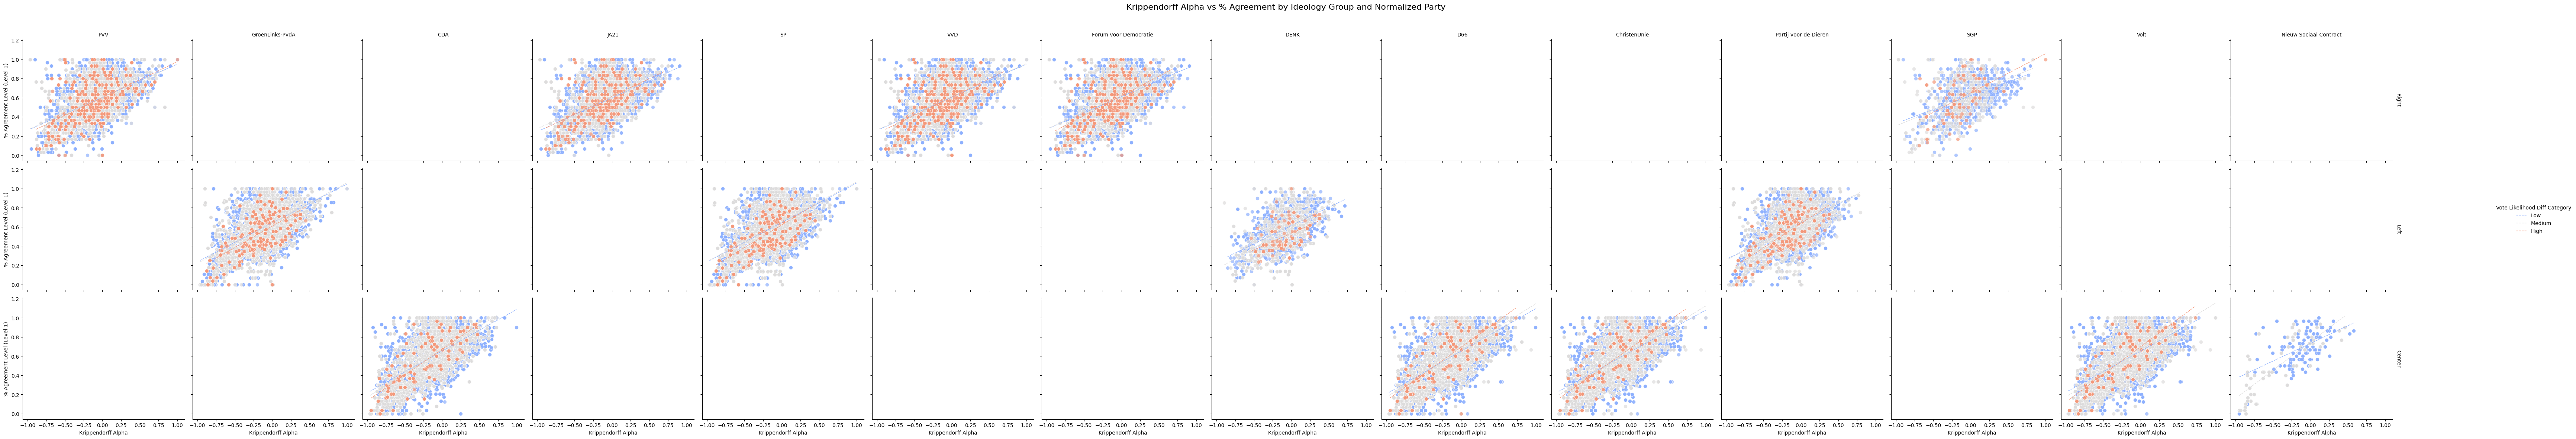

In [358]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data (e.g., bin vote likelihood into categories)
df_with_metrics_no_missings['vote_likelihood_diff_category'] = pd.cut(
    df_with_metrics_no_missings['vote_likelihood_diff'],
    bins=[-float('inf'), 1, 3, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Set up the facet grid
g = sns.FacetGrid(
    df_with_metrics_no_missings,
    row='Ideology_Group',
    col='normalized_party',
    hue='vote_likelihood_diff_category',
    height=4,
    aspect=1.2,
    margin_titles=True,
    palette='coolwarm',
)

# Map scatterplot to the grid
g.map(
    sns.scatterplot,
    'raw_krippendorff_alpha',  # X-axis
    '%_agreement_level_1',  # Y-axis
    alpha=0.7,
    s=50,  # Size of the markers
)

# Add regression lines
g.map(
    sns.regplot,
    'raw_krippendorff_alpha',
    '%_agreement_level_1',
    scatter=False,
    ci=None,
    line_kws={'linewidth': 1, 'linestyle': '--'},
)

# Add titles, labels, and legend
g.set_axis_labels('Krippendorff Alpha', '% Agreement Level (Level 1)')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.add_legend(title='Vote Likelihood Diff Category')

# Adjust the layout and show
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Krippendorff Alpha vs % Agreement by Ideology Group and Normalized Party', fontsize=16)
plt.show()


In [321]:
import statsmodels.formula.api as smf

mixed_model = smf.mixedlm(
    formula="raw_krippendorff_alpha ~ age_diff	+ dsc_diff + vote_likelihood_diff + Age_annotator_1 + Male_annotator_1 + Ideology_Group ",
    data=df_with_metrics_no_missings,
    groups=df_with_metrics_no_missings['group_interaction']   # Correctly handled as categorical
)

results = mixed_model.fit()
print(results.summary())

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: raw_krippendorff_alpha
No. Observations: 318396  Method:             REML                  
No. Groups:       32984   Scale:              0.0700                
Min. group size:  1       Log-Likelihood:     -48594.8560           
Max. group size:  25      Converged:          Yes                   
Mean group size:  9.7                                               
--------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                -0.168    0.004 -43.244 0.000 -0.175 -0.160
Ideology_Group[T.Left]    0.041    0.002  18.000 0.000  0.037  0.046
Ideology_Group[T.Right]   0.102    0.002  41.731 0.000  0.097  0.107
age_diff                 -0.001    0.000 -12.578 0.000 -0.001 -0.000
dsc_diff                 -0.026    0.001 -19.174 0

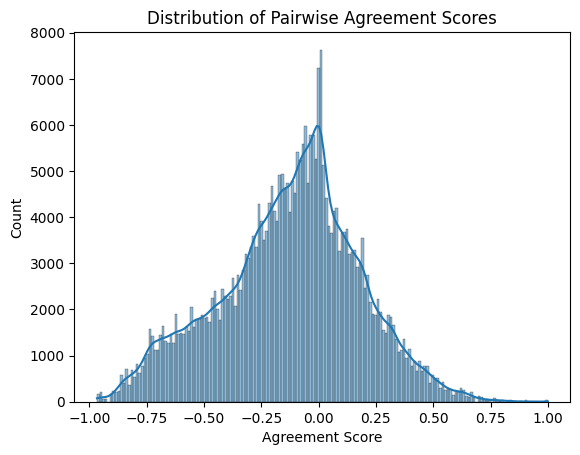

In [359]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairwise score distribution
sns.histplot(df_with_metrics_no_missings['raw_krippendorff_alpha'], kde=True)
plt.title("Distribution of Pairwise Agreement Scores")
plt.xlabel("Agreement Score")
plt.show()



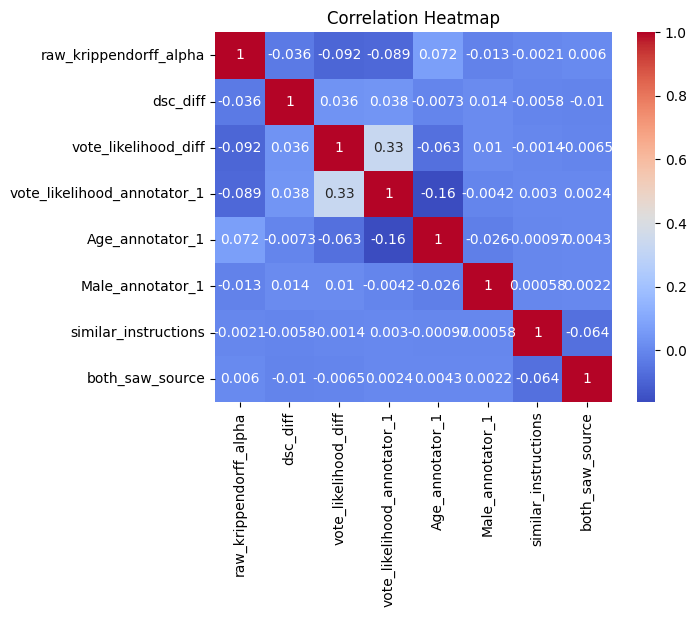

In [361]:
correlation_matrix = df_with_metrics_no_missings[['raw_krippendorff_alpha',  'dsc_diff',  'vote_likelihood_diff',  'vote_likelihood_annotator_1', 'Age_annotator_1', 'Male_annotator_1' , 'similar_instructions', 'both_saw_source']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [391]:
df_with_metrics_no_missings

,tweet_id,normalized_party,Ideology_Group,uid_1,uid_2,age_diff,gender_diff,dsc_diff,vote_likelihood_diff,Age_annotator_1,...,%_agreement_level_0,krippendorff_alpha_level_0,%_agreement_level_1,krippendorff_alpha_level_1,%_agreement_level_2,krippendorff_alpha_level_2,group_interaction,vote_likelihood_diff_category,vote_likelihood_recode,age_diff_bin
0,1212651012370120704,PVV,Right,266502,266511,20,0.0,1.261548,0.0,45,...,0.266667,1.0,0.633333,0.740205,0.900000,0.478805,266502_1212651012370120704,Low,0,10-20
1,1212651012370120704,PVV,Right,266502,266515,16,0.0,0.253923,0.0,45,...,0.333333,1.0,0.600000,0.867156,0.800000,0.656451,266502_1212651012370120704,Low,0,10-20
2,1212651012370120704,PVV,Right,266502,266518,20,0.0,0.217440,1.0,45,...,0.200000,1.0,0.600000,0.569168,0.966667,0.218491,266502_1212651012370120704,Low,0,10-20
3,1212651012370120704,PVV,Right,266502,266519,15,0.0,0.171889,0.0,45,...,0.233333,1.0,0.700000,0.649313,0.966667,0.455340,266502_1212651012370120704,Low,0,10-20
4,1212651012370120704,PVV,Right,266502,267068,7,0.0,0.097247,0.0,45,...,0.133333,1.0,0.466667,0.502537,0.700000,0.208095,266502_1212651012370120704,Low,0,0-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319108,1762600394004250880,JA21,Right,268037,268217,19,0.0,0.827780,3.0,49,...,0.066667,1.0,0.633333,0.267786,0.900000,0.141132,268037_1762600394004250880,Medium,0,10-20
319109,1762600394004250880,JA21,Right,268037,268267,6,0.0,0.217355,1.0,49,...,0.166667,1.0,0.266667,0.892857,0.700000,0.353283,268037_1762600394004250880,Low,0,0-10
319110,1762600394004250880,JA21,Right,268123,268217,4,0.0,0.073694,3.0,26,...,0.333333,1.0,0.900000,0.231304,1.000000,0.156458,268123_1762600394004250880,Medium,0,0-10
319111,1762600394004250880,JA21,Right,268123,268267,29,0.0,0.684119,1.0,26,...,0.200000,1.0,0.700000,0.492374,0.866667,0.381560,268123_1762600394004250880,Low,0,20-30


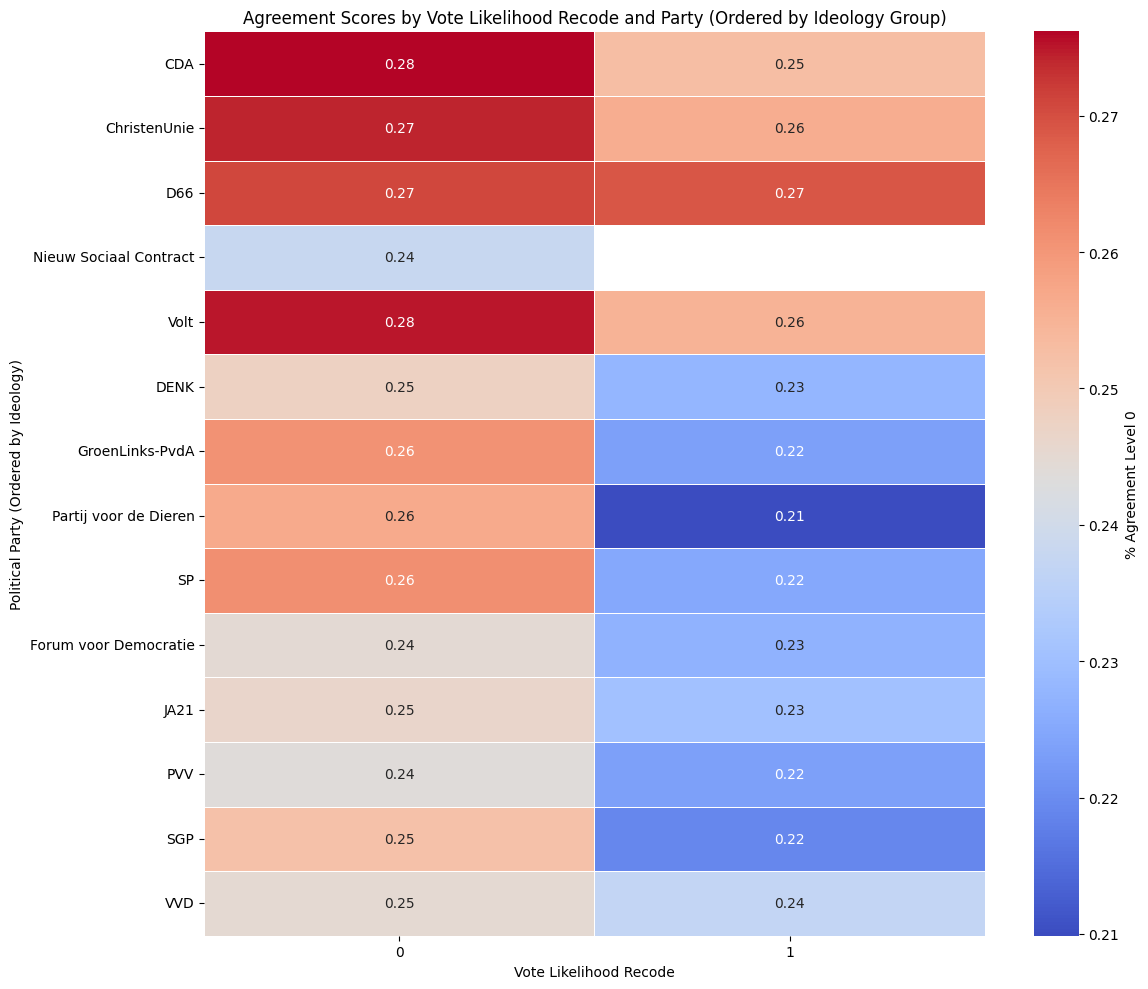

In [394]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sort by Ideology_Group and normalized_party for proper order
df_with_metrics_no_missings = df_with_metrics_no_missings.sort_values(by=['Ideology_Group', 'normalized_party'])

# Group data by normalized_party and vote_likelihood_recode, calculate mean for agreement
party_grouped = df_with_metrics_no_missings.groupby(['Ideology_Group', 'normalized_party', 'vote_likelihood_recode'])[
    '%_agreement_level_0'
].mean().reset_index()

# Pivot data to prepare for heatmap
heatmap_data = party_grouped.pivot(index='normalized_party', columns='vote_likelihood_recode', values='%_agreement_level_0')

# Sort the index by Ideology_Group (preserves grouping of parties by ideology)
heatmap_data = heatmap_data.reindex(
    df_with_metrics_no_missings[['Ideology_Group', 'normalized_party']]
    .drop_duplicates()
    .sort_values(by=['Ideology_Group', 'normalized_party'])['normalized_party']
)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': '% Agreement Level 0'})
plt.title("Agreement Scores by Vote Likelihood Recode and Party (Ordered by Ideology Group)")
plt.xlabel("Vote Likelihood Recode")
plt.ylabel("Political Party (Ordered by Ideology)")
plt.tight_layout()
plt.show()


/home/akroon/.local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



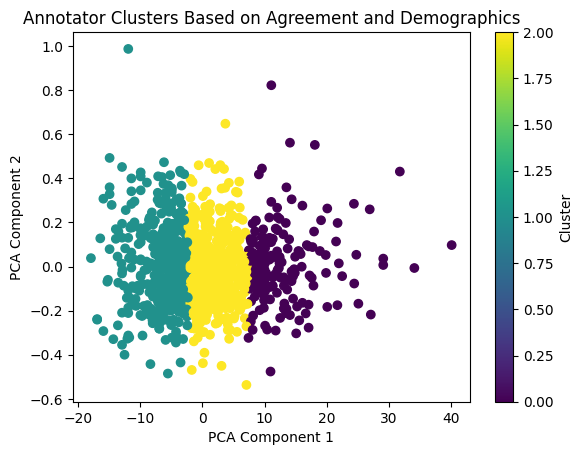

In [385]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Aggregate metrics by annotator
annotator_metrics = df_with_metrics_no_missings.groupby('uid_1')[['%_agreement_level_0', '%_agreement_level_1', '%_agreement_level_2', 'age_diff', 'gender_diff']].mean()

# Reduce dimensions using PCA
pca = PCA(n_components=2)
annotator_pca = pca.fit_transform(annotator_metrics)

# Cluster using K-means
kmeans = KMeans(n_clusters=3, random_state=0).fit(annotator_pca)
annotator_metrics['Cluster'] = kmeans.labels_

# Visualize clusters
plt.scatter(annotator_pca[:, 0], annotator_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("Annotator Clusters Based on Agreement and Demographics")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()


/tmp/ipykernel_3997897/924661666.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



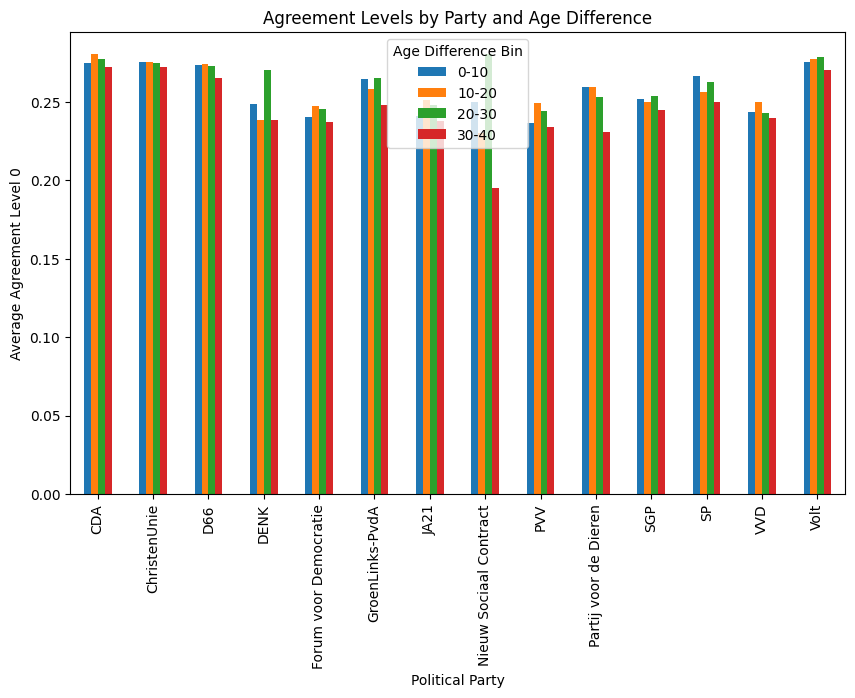

In [388]:
import numpy as np

# Bin age differences
df_with_metrics_no_missings['age_diff_bin'] = pd.cut(df_with_metrics_no_missings['age_diff'], bins=[0, 10, 20, 30, 40], labels=['0-10', '10-20', '20-30', '30-40'])

# Group by party and age difference bin
age_party_agreement = df_with_metrics_no_missings.groupby(['normalized_party', 'age_diff_bin'])['%_agreement_level_0'].mean().unstack()

# Plot grouped bar chart
age_party_agreement.plot(kind='bar', figsize=(10, 6))
plt.title("Agreement Levels by Party and Age Difference")
plt.xlabel("Political Party")
plt.ylabel("Average Agreement Level 0")
plt.legend(title="Age Difference Bin")
plt.show()


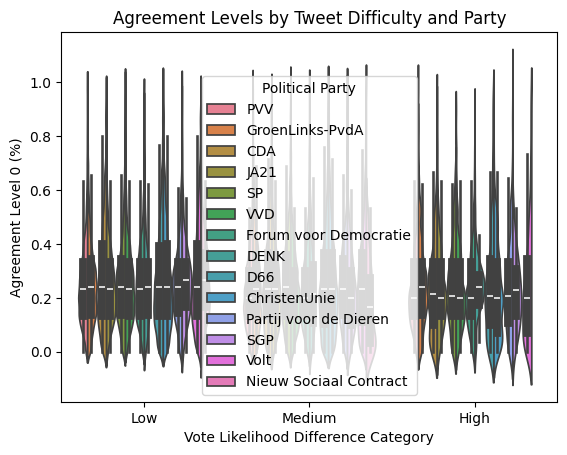

In [389]:
sns.violinplot(
    data=df_with_metrics_no_missings, 
    x='vote_likelihood_diff_category', 
    y='%_agreement_level_0', 
    hue='normalized_party', 
    split=True
)
plt.title("Agreement Levels by Tweet Difficulty and Party")
plt.xlabel("Vote Likelihood Difference Category")
plt.ylabel("Agreement Level 0 (%)")
plt.legend(title="Political Party")
plt.show()


In [366]:
df_with_metrics_no_missings['vote_likelihood_annotator_1'].value_counts()

df_with_metrics_no_missings['vote_likelihood_recode'] = df_with_metrics_no_missings['vote_likelihood_annotator_1'].apply(
    lambda x: 'High Likely' if x == 5 else 0
)


df_with_metrics_no_missings['vote_likelihood_recode'].value_counts()

/tmp/ipykernel_3997897/1271661777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_metrics_no_missings['vote_likelihood_recode'] = df_with_metrics_no_missings['vote_likelihood_annotator_1'].apply(


0              301421
High Likely     16975
Name: vote_likelihood_recode, dtype: int64

In [410]:
df_with_metrics_no_missings[['%_agreement_level_1', 'vote_likelihood_diff', 'vote_likelihood_recode', 'vote_likelihood_diff_binned' ]]

,%_agreement_level_1,vote_likelihood_diff,vote_likelihood_recode,vote_likelihood_diff_binned
603,0.931034,2.0,0,High
604,0.965517,3.0,0,High
605,0.862069,1.0,0,Low
606,0.379310,3.0,0,High
607,0.965517,1.0,0,Low
...,...,...,...,...
317955,0.533333,1.0,0,Low
317956,0.666667,1.0,0,Low
317957,0.600000,1.0,0,Low
317958,0.533333,1.0,0,Low


/home/akroon/.local/lib/python3.8/site-packages/seaborn/axisgrid.py:723: UserWarning:

Using the barplot function without specifying `hue_order` is likely to produce an incorrect plot.

/home/akroon/.local/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/home/akroon/.local/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




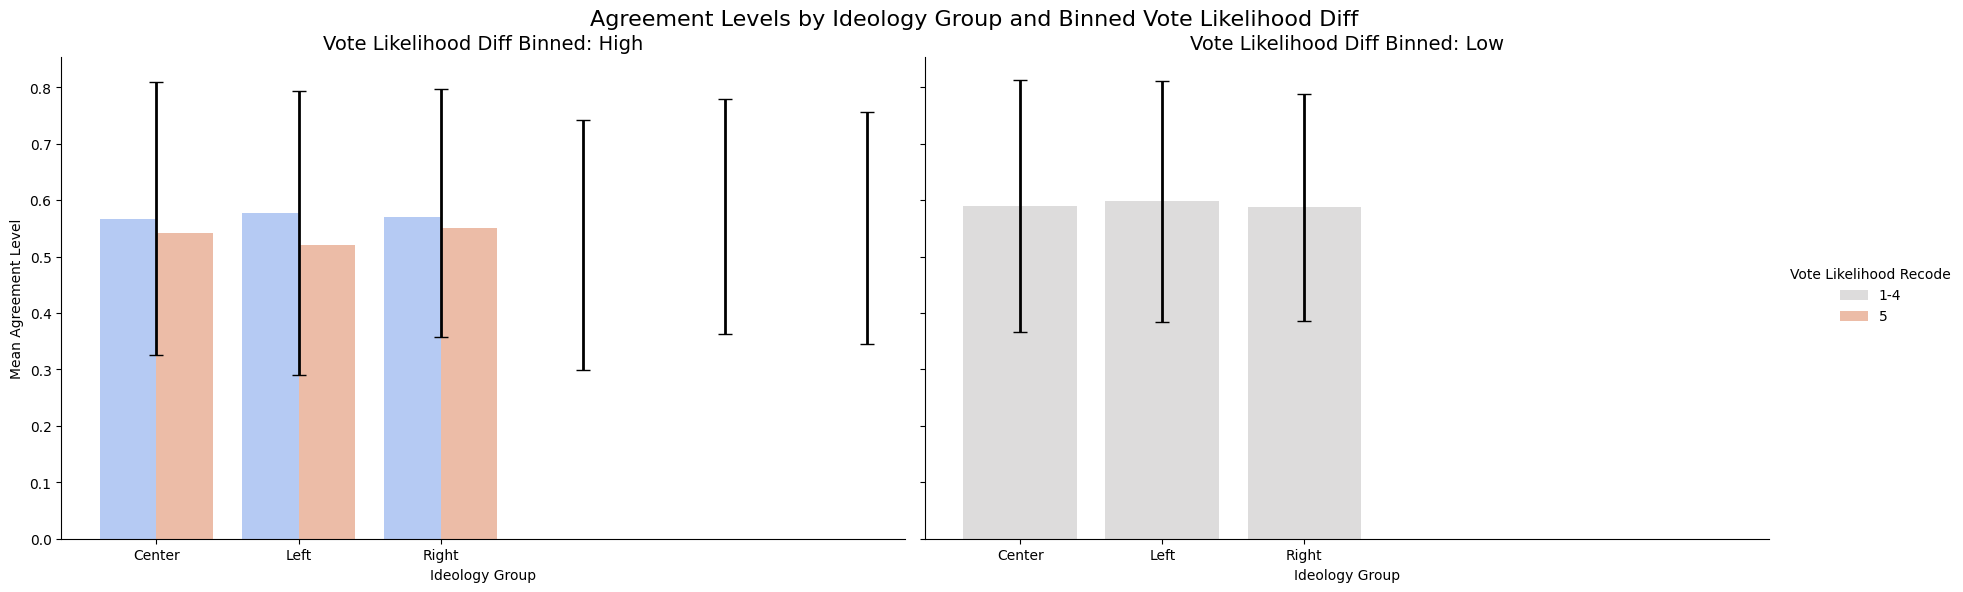

In [405]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming `df_with_metrics_no_missings` already exists

# Bin `vote_likelihood_diff` into two categories: Low and High
threshold = df_with_metrics_no_missings['vote_likelihood_diff'].median()  # You can change this threshold as needed
df_with_metrics_no_missings['vote_likelihood_diff_binned'] = df_with_metrics_no_missings['vote_likelihood_diff'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

# Recode `vote_likelihood_annotator_1`: 5 as 1 (High Likely), and 4, 3, 2, 1 as 0
df_with_metrics_no_missings['vote_likelihood_recode'] = df_with_metrics_no_missings['vote_likelihood_annotator_1'].apply(
    lambda x: 1 if x == 5 else 0
)

# Aggregate data for the plot
agg_values = df_with_metrics_no_missings.groupby(
    ['Ideology_Group', 'vote_likelihood_diff_binned', 'vote_likelihood_recode']
)['%_agreement_level_1'].agg(['mean', 'std']).reset_index()

# Map the binary values back to labels for readability
agg_values['vote_likelihood_recode'] = agg_values['vote_likelihood_recode'].map({1: '5', 0: '1-4'})

# Set up FacetGrid to create separate subplots for each bin of vote_likelihood_diff_binned
g = sns.FacetGrid(
    agg_values,
    col='vote_likelihood_diff_binned',  # Create separate plots for Low and High bins
    sharey=True,  # Share the y-axis across all subplots
    height=6,
    aspect=1.5
)

# Map barplot to the FacetGrid
g.map(
    sns.barplot,
    'Ideology_Group',
    'mean',
    'vote_likelihood_recode',
    order=df_with_metrics_no_missings['Ideology_Group'].unique(),
    palette='coolwarm',
    ci=None
)

# Add error bars
for ax, diff in zip(g.axes.flat, agg_values['vote_likelihood_diff_binned'].unique()):
    subset = agg_values[agg_values['vote_likelihood_diff_binned'] == diff]
    for i in range(len(subset)):
        ax.errorbar(
            x=i,  # Adjust x position for each category
            y=subset.iloc[i]['mean'],  # Mean value
            yerr=subset.iloc[i]['std'],  # Standard deviation
            fmt='none',  # No marker
            color='black',  # Error bar color
            capsize=5,  # End caps size
            elinewidth=2  # Error bar thickness
        )

# Add titles, labels, and legends
g.set_titles(col_template='Vote Likelihood Diff Binned: {col_name}', size=14)
g.set_axis_labels('Ideology Group', 'Mean Agreement Level')
g.add_legend(title='Vote Likelihood Recode')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Agreement Levels by Ideology Group and Binned Vote Likelihood Diff', fontsize=16)

# Show the plot
plt.show()


/home/akroon/.local/lib/python3.8/site-packages/seaborn/axisgrid.py:723: UserWarning:

Using the barplot function without specifying `hue_order` is likely to produce an incorrect plot.

/home/akroon/.local/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


/home/akroon/.local/lib/python3.8/site-packages/seaborn/axisgrid.py:854: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




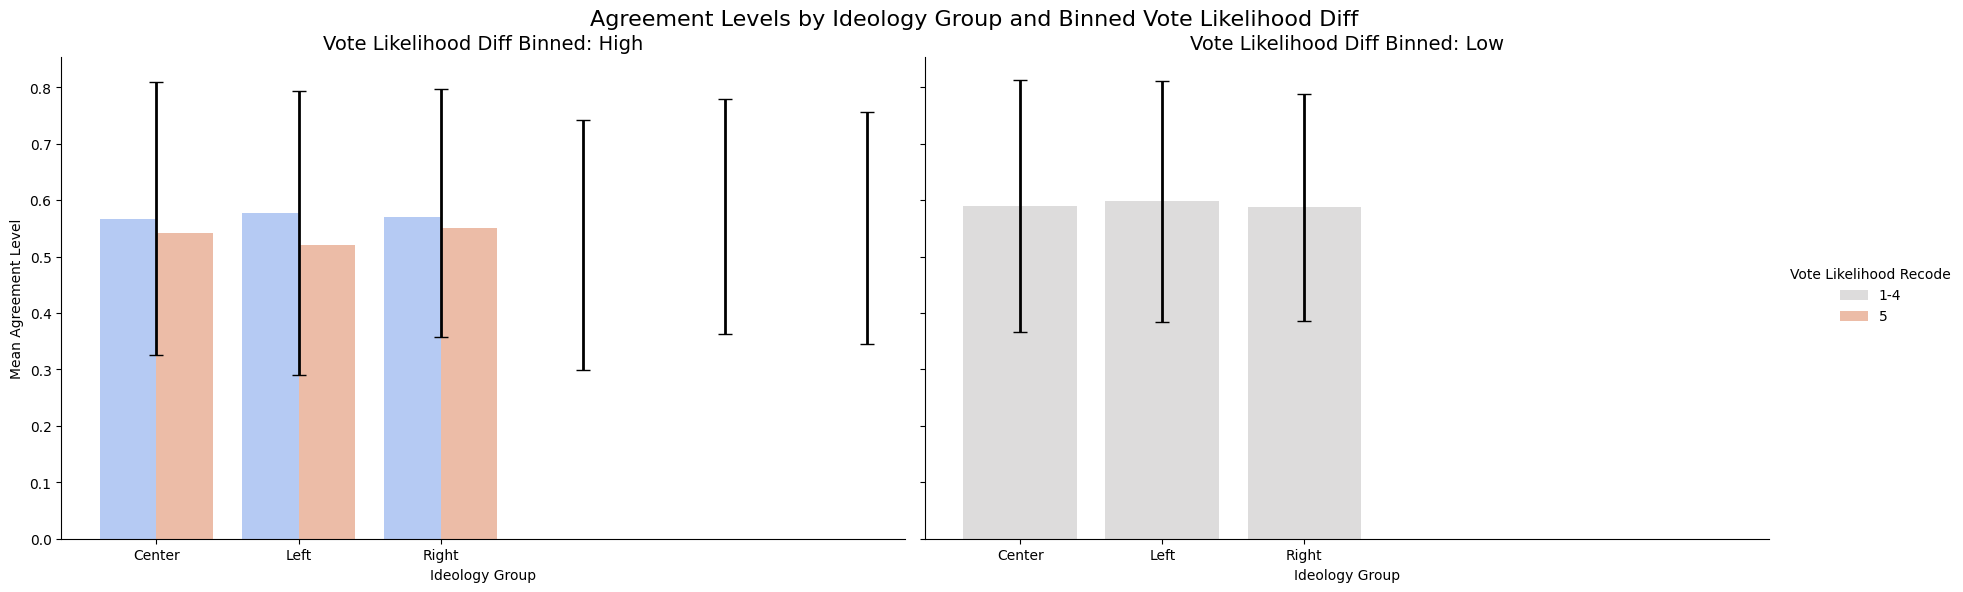

In [412]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df_with_metrics_no_missings is your DataFrame

# Bin `vote_likelihood_diff` into 'Low' and 'High' categories
threshold = df_with_metrics_no_missings['vote_likelihood_diff'].median()  # You can adjust this threshold
df_with_metrics_no_missings['vote_likelihood_diff_binned'] = df_with_metrics_no_missings['vote_likelihood_diff'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

# Recode `vote_likelihood_annotator_1`: 5 as 1 (High Likely), and 4, 3, 2, 1 as 0
df_with_metrics_no_missings['vote_likelihood_recode'] = df_with_metrics_no_missings['vote_likelihood_annotator_1'].apply(
    lambda x: 1 if x == 5 else 0
)

# Aggregate data for the plot
agg_values = df_with_metrics_no_missings.groupby(
    ['Ideology_Group', 'vote_likelihood_diff_binned', 'vote_likelihood_recode']
)['%_agreement_level_1'].agg(['mean', 'std']).reset_index()

# Map the binary values back to labels for readability
agg_values['vote_likelihood_recode'] = agg_values['vote_likelihood_recode'].map({1: '5', 0: '1-4'})

# Set up the FacetGrid to create separate plots for 'Low' and 'High' bins of vote_likelihood_diff
g = sns.FacetGrid(
    agg_values,
    col='vote_likelihood_diff_binned',  # Create separate columns for Low and High bins
    sharey=True,  # Share the y-axis across all subplots
    height=6,
    aspect=1.5
)

# Map barplot to the FacetGrid
g.map(
    sns.barplot,
    'Ideology_Group',
    'mean',
    'vote_likelihood_recode',
    order=df_with_metrics_no_missings['Ideology_Group'].unique(),
    palette='coolwarm',
    ci=None
)

# Add error bars for standard deviation
for ax, diff in zip(g.axes.flat, agg_values['vote_likelihood_diff_binned'].unique()):
    subset = agg_values[agg_values['vote_likelihood_diff_binned'] == diff]
    for i in range(len(subset)):
        ax.errorbar(
            x=i,  # Adjust x position for each category
            y=subset.iloc[i]['mean'],  # Mean value
            yerr=subset.iloc[i]['std'],  # Standard deviation
            fmt='none',  # No marker
            color='black',  # Error bar color
            capsize=5,  # End caps size
            elinewidth=2  # Error bar thickness
        )

# Add titles, labels, and legends
g.set_titles(col_template='Vote Likelihood Diff Binned: {col_name}', size=14)
g.set_axis_labels('Ideology Group', 'Mean Agreement Level')
g.add_legend(title='Vote Likelihood Recode')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Agreement Levels by Ideology Group and Binned Vote Likelihood Diff', fontsize=16)

# Show the plot
plt.show()


/tmp/ipykernel_3997897/3471584786.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


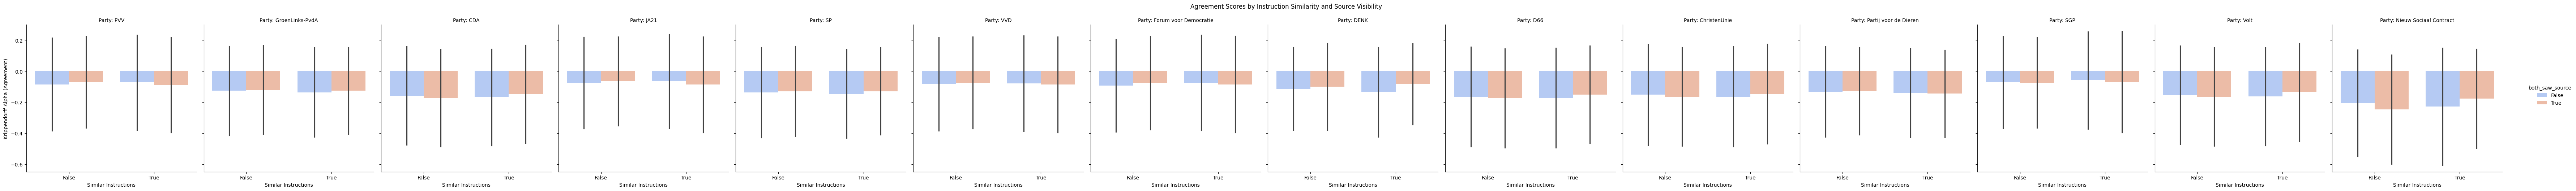

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a faceted bar plot
g = sns.catplot(
    data=df_with_metrics_no_missings,
    x="similar_instructions",
    y="raw_krippendorff_alpha",
    hue="both_saw_source",
    col="normalized_party",
    kind="bar",
    ci="sd",  # Show standard deviation error bars
    palette="coolwarm",
    height=5,
    aspect=1
)

# Add titles and labels
g.set_axis_labels("Similar Instructions", "Krippendorff Alpha (Agreement)")
g.set_titles("Party: {col_name}")
g.fig.suptitle("Agreement Scores by Instruction Similarity and Source Visibility", y=1.05)
plt.show()


/tmp/ipykernel_3997897/4241162036.py:13: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




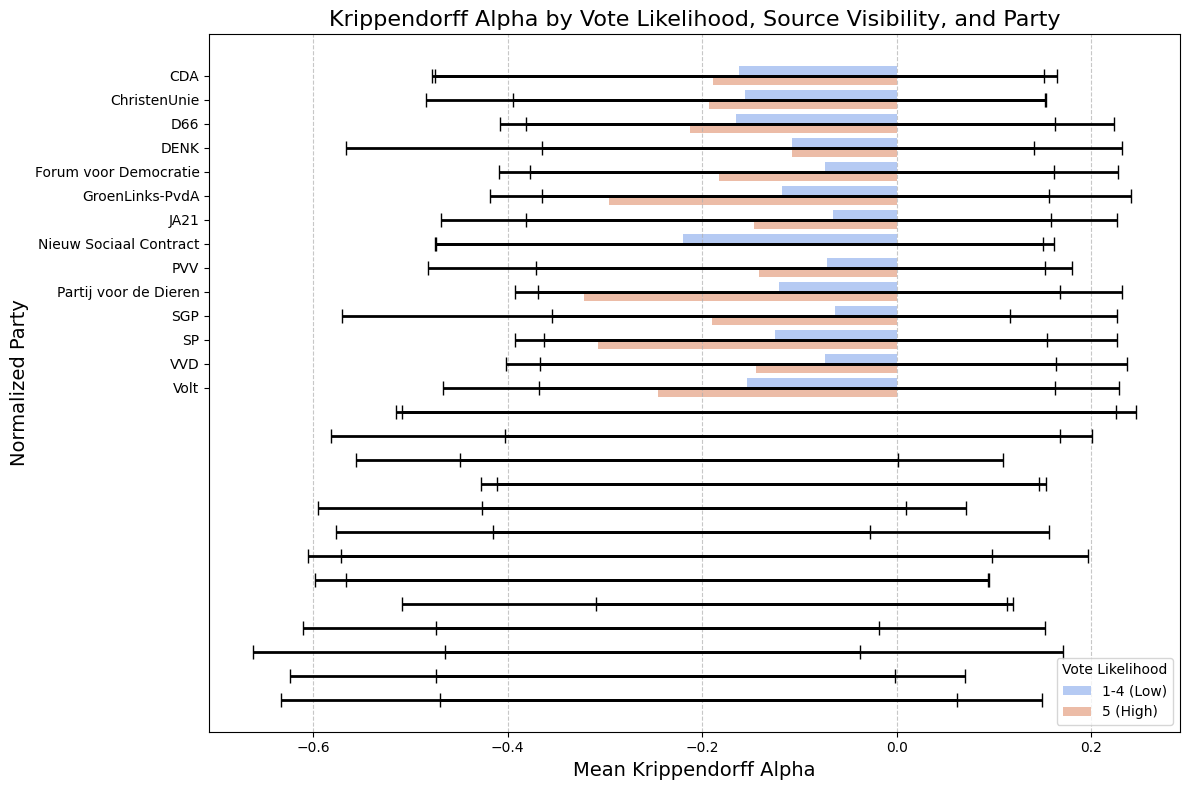

In [370]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregating data with the recoded variable
agg_values = df_with_metrics_no_missings.groupby(
    ['vote_likelihood_recode', 'both_saw_source', 'normalized_party']
)['raw_krippendorff_alpha'].agg(['mean', 'std']).reset_index()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a bar plot
sns.barplot(
    data=agg_values,
    x='mean',  # Mean Krippendorff Alpha scores
    y='normalized_party',  # Normalized party on the y-axis
    hue='vote_likelihood_recode',  # Hue for vote likelihood recode
    palette='coolwarm',
    ci=None  # Disable confidence interval bars
)

# Add error bars
for i in range(len(agg_values)):
    plt.errorbar(
        x=agg_values.iloc[i]['mean'],  # Mean value for the group
        y=i // len(agg_values['vote_likelihood_recode'].unique()),  # Adjust y position for groups
        xerr=agg_values.iloc[i]['std'],  # Standard deviation
        fmt='none',  # No marker
        color='black',  # Error bar color
        capsize=5,  # End caps size
        elinewidth=2  # Error bar thickness
    )

# Add titles and labels
plt.title('Krippendorff Alpha by Vote Likelihood, Source Visibility, and Party', fontsize=16)
plt.xlabel('Mean Krippendorff Alpha', fontsize=14)
plt.ylabel('Normalized Party', fontsize=14)
plt.legend(title='Vote Likelihood', labels=['1-4 (Low)', '5 (High)'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [35]:
print(f"NaN counts:\n{merged_data.isna().sum()}")


NaN counts:
uid_1                          0
uid_2                          0
age_diff                       0
gender_diff                    0
dsc_diff                       0
vote_likelihood_diff           0
tweet_id_x                     0
value_scaled_uid_1      28164280
tweet_id_y                     0
value_scaled_uid_2      28160520
dtype: int64


In [26]:
print(f"annotations_melted shape: {annotations_melted.shape}")
print(annotations_melted.head())


annotations_melted shape: (0, 3)
Empty DataFrame
Columns: [tweet_id, uid, value_scaled]
Index: []


In [29]:
import pandas as pd
import numpy as np
from krippendorff import krippendorff

# Example: Create a small mock dataset (replace with your actual df)
# For your case, df has been loaded as your main data source.
df_filtered = df[df['variable'] == 'stellingen.misinformation']

# Select relevant columns
annotations =df_filtered[['value_scaled', 'tweet_id', 'uid']]

# Pivot the data to have annotators as columns and tweets as rows
annotations_pivot = annotations.pivot_table(index='tweet_id', columns='uid', values='value_scaled', aggfunc='first')


annotations_pivot = annotations_pivot.fillna(np.nan)

# Calculate Krippendorff's Alpha
alpha = krippendorff.alpha(reliability_data=annotations_pivot.values)

print(f"Krippendorff's Alpha: {alpha}")

Krippendorff's Alpha: 0.348882556835


In [39]:
import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm


import pandas as pd
import numpy as np
from krippendorff import krippendorff

# Example: Create a small mock dataset (replace with your actual df)
# For your case, df has been loaded as your main data source.
df_filtered = df[df['variable'] == 'stellingen.misinformation']

# Select relevant columns
annotations =df_filtered[['value_scaled', 'tweet_id', 'uid']]

# Pivot the data to have annotators as columns and tweets as rows
annotations_pivot = annotations.pivot_table(index='tweet_id', columns='uid', values='value_scaled', aggfunc='first')


annotations_pivot = annotations_pivot.fillna(np.nan)

# Calculate Krippendorff's Alpha
alpha = krippendorff.alpha(reliability_data=annotations_pivot.values)

print(f"Krippendorff's Alpha: {alpha}")
# Sample Data: Assuming 'df_filtered' contains the main data with annotator details
# Select the relevant columns for the similarity calculations
annotators = df_filtered[['uid', 'Age', 'Male', 'dsc', 'vote_likelihood_score']]

# Function to calculate pairwise differences efficiently using combinations
def calculate_pairwise_differences(df):
    # Create a new DataFrame to store pairwise differences
    # Initialize empty lists to hold the results
    uid_1_list, uid_2_list, age_diff_list, gender_diff_list, dsc_diff_list, vote_likelihood_diff_list = [], [], [], [], [], []

    # Use combinations to generate unique pairs of annotators (by their row index positions)
    annotator_pairs = combinations(df.index, 2)

    # Wrap the loop with tqdm to track progress
    for i, j in tqdm(annotator_pairs, total=len(df) * (len(df) - 1) // 2, desc="Calculating differences"):
        # Access the two annotators by their indices
        uid_1 = df.loc[i, 'uid']
        uid_2 = df.loc[j, 'uid']
        
        # Calculate the absolute differences for each variable
        age_diff = abs(df.loc[i, 'Age'] - df.loc[j, 'Age'])
        gender_diff = abs(df.loc[i, 'Male'] - df.loc[j, 'Male'])
        dsc_diff = abs(df.loc[i, 'dsc'] - df.loc[j, 'dsc'])
        vote_likelihood_diff = abs(df.loc[i, 'vote_likelihood_score'] - df.loc[j, 'vote_likelihood_score'])

        # Append the results to the lists
        uid_1_list.append(uid_1)
        uid_2_list.append(uid_2)
        age_diff_list.append(age_diff)
        gender_diff_list.append(gender_diff)
        dsc_diff_list.append(dsc_diff)
        vote_likelihood_diff_list.append(vote_likelihood_diff)

    # Create a DataFrame from the lists
    df_diff = pd.DataFrame({
        'uid_1': uid_1_list,
        'uid_2': uid_2_list,
        'age_diff': age_diff_list,
        'gender_diff': gender_diff_list,
        'dsc_diff': dsc_diff_list,
        'vote_likelihood_diff': vote_likelihood_diff_list
    })

    return df_diff

# Subset testing: Work with a smaller sample to speed up the initial test
# Calculate pairwise differences for the subset

sample_annotators = annotators.sample(200, random_state=42)  # 

similarity_metrics = calculate_pairwise_differences(sample_annotators )

# Inspect the similarity metrics
print(similarity_metrics.head())


Calculating differences: 100%|██████████| 19900/19900 [00:01<00:00, 18560.16it/s]


    uid_1   uid_2  age_diff  gender_diff  dsc_diff  vote_likelihood_diff
0  267994  267006         1          1.0  0.363861                   0.0
1  267994  266367         1          1.0  0.285766                   1.0
2  267994  267582        23          1.0  0.337271                   1.0
3  267994  267280        10          1.0  0.632129                   0.0
4  267994  267517        14          1.0  0.395115                   1.0


In [40]:
print(sample_annotators[['Age', 'Male', 'dsc', 'vote_likelihood_score']].isnull().sum())

Age                      0
Male                     0
dsc                      0
vote_likelihood_score    0
dtype: int64


In [45]:
import pandas as pd

# Assuming similarity_metrics and annotations DataFrames are already defined
# Merging the similarity metrics with the annotations DataFrame on uid_1 and uid_2
merged_data_1 = pd.merge(similarity_metrics, annotations, left_on='uid_1', right_on='uid', suffixes=('_uid1', '_uid1_data'))
merged_data_2 = pd.merge(merged_data_1, annotations, left_on='uid_2', right_on='uid', suffixes=('_uid2', '_uid2_data'))

# Inspect the columns of the merged DataFrame to understand what's there
print("Columns in the merged data:", merged_data_2.columns)

# Preview the first few rows of the merged data for better understanding
print(merged_data_2.head())

# Now you can adjust the column names in the selection based on what you see
# Example: Assume the correct names are 'value_scaled_uid2', 'tweet_id_uid2', etc.
# Replace the column selection with the correct ones
# Adjusting the column selection to match what's available in the DataFrame
final_data = merged_data_2[['uid_1', 'uid_2', 'age_diff', 'gender_diff', 'dsc_diff', 'vote_likelihood_diff',
                            'value_scaled_uid2', 'tweet_id_uid2', 
                            'value_scaled_uid2_data', 'tweet_id_uid2_data']]  # Remove missing columns

# Preview final dataset
print(final_data.head())


# Preview final dataset
print(final_data.head())


Columns in the merged data: Index(['uid_1', 'uid_2', 'age_diff', 'gender_diff', 'dsc_diff',
       'vote_likelihood_diff', 'value_scaled_uid2', 'tweet_id_uid2',
       'uid_uid2', 'value_scaled_uid2_data', 'tweet_id_uid2_data',
       'uid_uid2_data'],
      dtype='object')
    uid_1   uid_2  age_diff  gender_diff  dsc_diff  vote_likelihood_diff  \
0  267994  267006         1          1.0  0.363861                   0.0   
1  267994  267006         1          1.0  0.363861                   0.0   
2  267994  267006         1          1.0  0.363861                   0.0   
3  267994  267006         1          1.0  0.363861                   0.0   
4  267994  267006         1          1.0  0.363861                   0.0   

   value_scaled_uid2        tweet_id_uid2  uid_uid2  value_scaled_uid2_data  \
0                4.0  1430257219220742144    267994                     2.0   
1                4.0  1430257219220742144    267994                     1.0   
2                4.0  143025721

In [51]:
# Group by 'uid_1' and 'uid_2' and count the ratings for each pair
grouped_data = merged_data_2.groupby(['uid_1', 'uid_2']).size()

# Filter out the pairs that have more than one rating
valid_pairs = grouped_data[grouped_data > 1].index

# Extract the data for only the valid pairs
filtered_data = merged_data_2[merged_data_2.set_index(['uid_1', 'uid_2']).index.isin(valid_pairs)]

# Show the filtered data
print(filtered_data.head())


    uid_1   uid_2  age_diff  gender_diff  dsc_diff  vote_likelihood_diff  \
0  267994  267006         1          1.0  0.363861                   0.0   
1  267994  267006         1          1.0  0.363861                   0.0   
2  267994  267006         1          1.0  0.363861                   0.0   
3  267994  267006         1          1.0  0.363861                   0.0   
4  267994  267006         1          1.0  0.363861                   0.0   

   value_scaled_uid2        tweet_id_uid2  uid_uid2  value_scaled_uid2_data  \
0                4.0  1430257219220742144    267994                     2.0   
1                4.0  1430257219220742144    267994                     1.0   
2                4.0  1430257219220742144    267994                     5.0   
3                4.0  1430257219220742144    267994                     5.0   
4                4.0  1430257219220742144    267994                     1.0   

    tweet_id_uid2_data  uid_uid2_data  
0  1550554553980002306      

In [35]:
final_data = pd.concat([annotations, similarity_metrics[['age_diff', 'gender_diff', 'dsc_diff', 'vote_likelihood_diff']]], axis=1)
final_data.head()

,value_scaled,tweet_id,uid,age_diff,gender_diff,dsc_diff,vote_likelihood_diff
120247,1.0,1430257219220742144,267322.0,NaN,NaN,NaN,NaN
120251,1.0,1481269682619523072,267322.0,NaN,NaN,NaN,NaN
120255,1.0,1465587695179161603,267322.0,NaN,NaN,NaN,NaN
120259,1.0,1563198285778563074,267322.0,NaN,NaN,NaN,NaN
120263,1.0,1658579067157770243,267322.0,NaN,NaN,NaN,NaN


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Merge the ideological and personal characteristics data with the agreement data
annotator_data = df_filtered[['uid', 'Ideology_Group', 'vote_likelihood_score', 'dsc', 'Age', 'Male']]  # Add other characteristics
annotator_data = annotator_data.drop_duplicates()

# Add ideology to the annotations data
annotations_with_data = annotations.merge(annotator_data, on='uid')

# Perform a regression to see if ideology or personal characteristics predict the agreement
model = ols('value_scaled ~ Ideology_Group + vote_likelihood_score + dsc + Age + Male', data=annotations_with_data).fit()

# Print the summary of the regression
print(model.summary())


In [ ]:

annotations_pivot 

In [ ]:
df[df['variable'] == 'stellingen.misinformation']['value_scaled']

from sklearn.preprocessing import StandardScaler
data = df_filtered[['value_scaled', 'dsc', 'vote_likelihood_score']]
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data)


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df_filtered['cluster'] = kmeans.fit_predict(data_normalized)


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_normalized)
df_filtered['PCA1'] = pca_components[:, 0]
df_filtered['PCA2'] = pca_components[:, 1]

In [ ]:
df_filtered['vote

In [ ]:
data

In [ ]:
# Check for any missing values after imputation
print(df[['dsc', 'vote_likelihood_score', 'Ideology_Group']].isnull().sum())


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Step 1: Impute missing values for continuous columns (dsc, vote_likelihood_score)
imputer_continuous = SimpleImputer(strategy='mean')
df[['dsc', 'vote_likelihood_score']] = imputer_continuous.fit_transform(df[['dsc', 'vote_likelihood_score']])

# Step 2: Impute missing values for Ideology_Group (using most frequent category)
imputer_categorical = SimpleImputer(strategy='most_frequent')
df['Ideology_Group'] = imputer_categorical.fit_transform(df[['Ideology_Group']])

# Step 3: Filter relevant data for 'stellingen.misinformation'
df_filtered = df[df['variable'] == 'stellingen.misinformation']

# Step 4: Normalize continuous variables (dsc, vote_likelihood_score)
data = df_filtered[['dsc', 'vote_likelihood_score', 'Ideology_Group']]
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data[['dsc', 'vote_likelihood_score']])

# Step 5: Ensure Ideology_Group is properly encoded as numeric
data_normalized = pd.DataFrame(data_normalized, columns=['dsc', 'vote_likelihood_score'])
data_normalized['Ideology_Group'] = df_filtered['Ideology_Group'].astype('category').cat.codes

# Step 6: Drop rows with NaN values just in case
data_normalized = data_normalized.dropna()

# Step 7: Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df_filtered = df_filtered.loc[data_normalized.index]  # Align df_filtered with data_normalized
df_filtered['cluster'] = kmeans.fit_predict(data_normalized)

# Step 8: Reduce dimensions using t-SNE (to 2D for visualization)
tsne = TSNE(n_components=2, random_state=42)
tsne_components = tsne.fit_transform(data_normalized)

# Step 9: Add t-SNE components to the dataframe for plotting
df_filtered['tSNE1'] = tsne_components[:, 0]
df_filtered['tSNE2'] = tsne_components[:, 1]

# Step 10: Plot the clusters with t-SNE visualization
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_filtered, x='tSNE1', y='tSNE2', hue='cluster', palette='viridis', s=100, alpha=0.7, edgecolor='w')
plt.title("t-SNE Visualization of Annotator Clusters", fontsize=16)
plt.xlabel("t-SNE Component 1", fontsize=14)
plt.ylabel("t-SNE Component 2", fontsize=14)
plt.legend(title="Cluster", loc='best')
plt.show()


In [ ]:
# Step 1: Print the cluster centers to understand the mean feature values for each cluster
print("Cluster Centers (mean values for each feature in the cluster):")
print(kmeans.cluster_centers_)

# Step 2: Inspect the distribution of samples across clusters
cluster_counts = df_filtered['cluster'].value_counts()
print("\nNumber of samples per cluster:")
print(cluster_counts)

# Step 3: Analyze the relationship between clusters and features
# You can look at the mean of each feature in each cluster
cluster_means = df_filtered.groupby('cluster')[['dsc', 'vote_likelihood_score', 'Ideology_Group']].mean()
print("\nMean values of features for each cluster:")
print(cluster_means)

# Step 4: You can also visualize the clusters based on the t-SNE components
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_filtered, x='tSNE1', y='tSNE2', hue='cluster', palette='viridis', s=100, alpha=0.7, edgecolor='w')
plt.title("t-SNE Visualization of Annotator Clusters", fontsize=16)
plt.xlabel("t-SNE Component 1", fontsize=14)
plt.ylabel("t-SNE Component 2", fontsize=14)
plt.legend(title="Cluster", loc='best')
plt.show()


In [ ]:
# Check for missing values in the relevant columns right before K-Means
print(data_normalized.isnull().sum())


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and the necessary columns are already in place

# Create a binary variable for vote likelihood
df['vote_likelihood_binary'] = df['vote_likelihood_score'].apply(lambda x: 1 if x > 4 else 0)

# Calculate mean and standard deviation for value_scaled by vote_likelihood_binary and normalized_party
agg_values = df.groupby(['vote_likelihood_binary', 'normalized_party'])['value_scaled'].agg(['mean', 'std']).reset_index()

# Display the aggregated values (mean and standard deviation)
print(agg_values)

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a bar plot for mean value_scaled with error bars representing standard deviation
sns.barplot(
    data=agg_values,
    y='normalized_party',  # Move parties to the y-axis
    x='mean',  # Mean values on the x-axis
    hue='vote_likelihood_binary',  # Different colors for each vote likelihood category
    palette='coolwarm',
    ci=None  # Disable the internal confidence interval
)

# Add error bars representing the standard deviation
for i in range(len(agg_values)):
    plt.errorbar(
        x=agg_values.iloc[i]['mean'],  # Position of the bar (mean value)
        y=i // 2,  # Adjust the y position for each bar (grouped by vote_likelihood_binary)
        xerr=agg_values.iloc[i]['std'],  # Standard deviation as the error
        fmt='none',  # No marker
        color='black',  # Error bar color
        capsize=5,  # Size of the caps at the end of error bars
        elinewidth=2  # Thickness of the error bars
    )

# Add titles and labels
plt.title('Mean Value Scaled by Vote Likelihood and Normalized Party', fontsize=16)
plt.ylabel('Normalized Party', fontsize=14)
plt.xlabel('Mean Value Scaled', fontsize=14)
plt.legend(title='Vote Likelihood (Binary)', labels=['Low (0)', 'High (1)'])
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter the DataFrame to only include rows where the 'variable' column is 'stellingen.misinformation'
df_filtered = df[df['variable'] == 'stellingen.sentiment'].copy()

# Create a binary variable for vote likelihood
df_filtered['vote_likelihood_binary'] = df_filtered['vote_likelihood_score'].apply(lambda x: 1 if x > 4 else 0)

# Calculate mean and standard deviation for value_scaled by vote_likelihood_binary and normalized_party
agg_values = df_filtered.groupby(
    ['vote_likelihood_binary', 'normalized_party', 'source_shown']
)['value_scaled'].agg(['mean', 'std']).reset_index()

# Order of the political parties (left to right, green to red)
party_order = [
    'GroenLinks-PvdA', 'SP', 'Partij voor de Dieren', 'ChristenUnie', 'D66', 'Volt', 
    'CDA', 'Nieuw Sociaal Contract', 'VVD', 'DENK', 'JA21', 'SGP', 'PVV', 'Forum voor Democratie'
]

# Generate a gradient of colors from green (left) to red (right) for the y-axis labels
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("green_to_red", ["green", "yellow", "red"], N=len(party_order))
party_colors = [cmap(i / (len(party_order) - 1)) for i in range(len(party_order))]

# Create a mapping of political parties to numeric indices for vertical positioning
party_index = {party: index for index, party in enumerate(party_order)}

# Add a new column 'party_index' based on the party_order
agg_values['party_index'] = agg_values['normalized_party'].map(party_index)

# Set up the Matplotlib figure with two columns for source_shown
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Define color mapping for vote likelihood
vote_colors = {0: 'black', 1: 'green'}
vote_labels = {0: 'Not Likely to Vote', 1: 'Likely to Vote'}

# Small vertical offset for `vote_likelihood_binary=1`
vertical_offset = 0.2

# Iterate over the two `source_shown` values to create subplots
for i, source_shown in enumerate([False, True]):
    ax = axes[i]
    
    # Filter the data for the current `source_shown` value
    subset_data = agg_values[agg_values['source_shown'] == source_shown]
    
    # Plot data for each `vote_likelihood_binary` category
    for vote_likelihood in [0, 1]:
        category_data = subset_data[subset_data['vote_likelihood_binary'] == vote_likelihood]
        
        # Apply a vertical offset to `vote_likelihood_binary=1`
        y_positions = category_data['party_index'] + (vertical_offset if vote_likelihood == 1 else 0)
        
        # Plot the mean values (larger points for prominence)
        ax.scatter(
            category_data['mean'], 
            y_positions, 
            label=vote_labels[vote_likelihood] if source_shown == False else None,  # Add labels only for the first subplot to avoid duplicates
            color=vote_colors[vote_likelihood],
            s=100  # Larger size for the scatter points
        )
        
        # Add error bars for standard deviation (smaller size)
        for j in range(len(category_data)):
            ax.errorbar(
                x=category_data.iloc[j]['mean'], 
                y=y_positions.iloc[j], 
                xerr=category_data.iloc[j]['std'], 
                fmt='o', 
                color=vote_colors[vote_likelihood], 
                capsize=3,  # Smaller cap size
                elinewidth=1  # Thinner error bars
            )
    
    # Add subplot title
    ax.set_title(f'Source {"Shown" if source_shown else "Not Shown"}', fontsize=14)
    ax.set_xlabel('Mean Value Scaled', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Set y-axis ticks and labels
    ax.set_yticks(range(len(party_order)))
    ax.set_yticklabels(party_order, fontsize=10)
    for tick_label, color in zip(ax.get_yticklabels(), party_colors):
        tick_label.set_color(color)
    if i == 0:
        ax.set_ylabel('Normalized Party', fontsize=12)

# Add a legend to the first subplot only
axes[0].legend(title='Vote Likelihood', fontsize=10)

# Tighten layout for better visualization
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df is your DataFrame and the necessary columns are already in place

# Create a binary variable for vote likelihood
df['vote_likelihood_binary'] = df['vote_likelihood_score'].apply(lambda x: 1 if x > 4 else 0)

# Calculate mean and standard deviation for value_scaled by vote_likelihood_binary and normalized_party
agg_values = df.groupby(['vote_likelihood_binary', 'normalized_party'])['value_scaled'].agg(['mean', 'std']).reset_index()

# Display the aggregated values (mean and standard deviation)
print(agg_values)

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a bar plot for mean value_scaled with error bars representing standard deviation
sns.barplot(
    data=agg_values,
    y='normalized_party',  # Move parties to the y-axis
    x='mean',  # Mean values on the x-axis
    hue='vote_likelihood_binary',  # Different colors for each vote likelihood category
    palette='coolwarm',
    ci=None  # Disable the internal confidence interval
)

# Add error bars representing the standard deviation
for i in range(len(agg_values)):
    plt.errorbar(
        x=agg_values.iloc[i]['mean'],  # Position of the bar (mean value)
        y=i // 2,  # Adjust the y position for each bar (grouped by vote_likelihood_binary)
        xerr=agg_values.iloc[i]['std'],  # Standard deviation as the error
        fmt='none',  # No marker
        color='black',  # Error bar color
        capsize=5,  # Size of the caps at the end of error bars
        elinewidth=2  # Thickness of the error bars
    )

# Add titles and labels
plt.title('Mean Value Scaled by Vote Likelihood and Normalized Party', fontsize=16)
plt.ylabel('Normalized Party', fontsize=14)
plt.xlabel('Mean Value Scaled', fontsize=14)
plt.legend(title='Vote Likelihood (Binary)', labels=['Low (0)', 'High (1)'])
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter the DataFrame to only include rows where the 'variable' column is 'stellingen.misinformation'
df_filtered = df[df['variable'] == 'stellingen.misinformation'].copy()

# Create a binary variable for vote likelihood
df_filtered['vote_likelihood_binary'] = df_filtered['vote_likelihood_score'].apply(lambda x: 1 if x > 4 else 0)

# Create a categorical variable for DSC High and DSC Low
df_filtered['dsc_category'] = df_filtered['dsc'].apply(lambda x: 'DSC High' if x > 0.5 else 'DSC Low')

# Calculate mean and standard deviation for value_scaled by vote_likelihood_binary, dsc_category, and normalized_party
agg_values = df_filtered.groupby(
    ['vote_likelihood_binary', 'dsc_category', 'normalized_party', 'source_shown']
)['value_scaled'].agg(['mean', 'std']).reset_index()

# Order of the political parties (left to right, green to red)
party_order = [
    'GroenLinks-PvdA', 'SP', 'Partij voor de Dieren', 'ChristenUnie', 'D66', 'Volt', 
    'CDA', 'Nieuw Sociaal Contract', 'VVD', 'DENK', 'JA21', 'SGP', 'PVV', 'Forum voor Democratie'
]

# Generate a gradient of colors from green (left) to red (right) for the y-axis labels
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("green_to_red", ["green", "yellow", "red"], N=len(party_order))
party_colors = [cmap(i / (len(party_order) - 1)) for i in range(len(party_order))]

# Create a mapping of political parties to numeric indices for vertical positioning
party_index = {party: index for index, party in enumerate(party_order)}

# Add a new column 'party_index' based on the party_order
agg_values['party_index'] = agg_values['normalized_party'].map(party_index)

# Set up the Matplotlib figure with two columns for source_shown
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Define color mapping for vote likelihood and dsc_category
vote_colors = {0: 'black', 1: 'green'}
vote_labels = {0: 'Not Likely to Vote', 1: 'Likely to Vote'}

dsc_colors = {'DSC Low': 'blue', 'DSC High': 'orange'}
dsc_labels = {'DSC Low': 'DSC Low', 'DSC High': 'DSC High'}

# Small vertical offset for `vote_likelihood_binary=1` and `dsc_category`
vertical_offset = 0.2

# Iterate over the two `source_shown` values to create subplots
for i, source_shown in enumerate([False, True]):
    ax = axes[i]
    
    # Filter the data for the current `source_shown` value
    subset_data = agg_values[agg_values['source_shown'] == source_shown]
    
    # Plot data for each `vote_likelihood_binary` category
    for vote_likelihood in [0, 1]:
        category_data = subset_data[subset_data['vote_likelihood_binary'] == vote_likelihood]
        
        # Apply a vertical offset to `vote_likelihood_binary=1`
        y_positions = category_data['party_index'] + (vertical_offset if vote_likelihood == 1 else 0)
        
        # Plot the mean values (larger points for prominence)
        ax.scatter(
            category_data['mean'], 
            y_positions, 
            label=vote_labels[vote_likelihood] if source_shown == False else None,  # Add labels only for the first subplot to avoid duplicates
            color=vote_colors[vote_likelihood],
            s=100  # Larger size for the scatter points
        )
        
        # Add error bars for standard deviation (smaller size)
        for j in range(len(category_data)):
            ax.errorbar(
                x=category_data.iloc[j]['mean'], 
                y=y_positions.iloc[j], 
                xerr=category_data.iloc[j]['std'], 
                fmt='o', 
                color=vote_colors[vote_likelihood], 
                capsize=3,  # Smaller cap size
                elinewidth=1  # Thinner error bars
            )
    
    # Plot data for DSC Low and DSC High categories
    for dsc_category in ['DSC Low', 'DSC High']:
        category_data = subset_data[subset_data['dsc_category'] == dsc_category]
        
        # Apply vertical offset for DSC High category
        y_positions = category_data['party_index'] + (vertical_offset if dsc_category == 'DSC High' else 0)
        
        # Plot the mean values for DSC categories
        ax.scatter(
            category_data['mean'], 
            y_positions, 
            label=dsc_labels[dsc_category] if source_shown == False else None,
            color=dsc_colors[dsc_category],
            s=100  # Larger size for the scatter points
        )
        
        # Add error bars for DSC categories
        for j in range(len(category_data)):
            ax.errorbar(
                x=category_data.iloc[j]['mean'], 
                y=y_positions.iloc[j], 
                xerr=category_data.iloc[j]['std'], 
                fmt='o', 
                color=dsc_colors[dsc_category], 
                capsize=3,  # Smaller cap size
                elinewidth=1  # Thinner error bars
            )
    
    # Add subplot title
    ax.set_title(f'Source {"Shown" if source_shown else "Not Shown"}', fontsize=14)
    ax.set_xlabel('Mean Value Scaled', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Set y-axis ticks and labels
    ax.set_yticks(range(len(party_order)))
    ax.set_yticklabels(party_order, fontsize=10)
    for tick_label, color in zip(ax.get_yticklabels(), party_colors):
        tick_label.set_color(color)
    if i == 0:
        ax.set_ylabel('Normalized Party', fontsize=12)

# Add a legend to the first subplot only
axes[0].legend(title='Vote Likelihood & DSC Category', fontsize=10)

# Tighten layout for better visualization
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter the DataFrame to only include rows where the 'variable' column is 'stellingen.misinformation'
df_filtered = df[df['variable'] == 'stellingen.misinformation'].copy()

# Create a binary variable for vote likelihood
df_filtered['vote_likelihood_binary'] = df_filtered['vote_likelihood_score'].apply(lambda x: 1 if x > 4 else 0)

# Calculate mean and standard deviation for value_scaled by vote_likelihood_binary and Ideology_Group
agg_values = df_filtered.groupby(
    ['vote_likelihood_binary', 'Ideology_Group', 'source_shown']
)['value_scaled'].agg(['mean', 'std']).reset_index()

# Define the correct order of the ideology groups
ideology_order = ['Left', 'Center Left', 'Center', 'Center Right', 'Right']

# Generate a gradient of colors from green (left) to red (right) for the y-axis labels
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("green_to_red", ["green", "yellow", "red"], N=len(ideology_order))
ideology_colors = [cmap(i / (len(ideology_order) - 1)) for i in range(len(ideology_order))]

# Create a mapping of ideology groups to numeric indices for vertical positioning
ideology_index = {group: index for index, group in enumerate(ideology_order)}

# Add a new column 'ideology_index' based on the ideology_order
agg_values['ideology_index'] = agg_values['Ideology_Group'].map(ideology_index)

# Set up the Matplotlib figure with two columns for source_shown
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Define color mapping for vote likelihood
vote_colors = {0: 'black', 1: 'green'}
vote_labels = {0: 'Not Likely to Vote', 1: 'Likely to Vote'}

# Small vertical offset for `vote_likelihood_binary=1`
vertical_offset = 0.2

# Iterate over the two `source_shown` values to create subplots
for i, source_shown in enumerate([False, True]):
    ax = axes[i]
    
    # Filter the data for the current `source_shown` value
    subset_data = agg_values[agg_values['source_shown'] == source_shown]
    
    # Plot data for each `vote_likelihood_binary` category
    for vote_likelihood in [0, 1]:
        category_data = subset_data[subset_data['vote_likelihood_binary'] == vote_likelihood]
        
        # Apply a vertical offset to `vote_likelihood_binary=1`
        y_positions = category_data['ideology_index'] + (vertical_offset if vote_likelihood == 1 else 0)
        
        # Plot the mean values (larger points for prominence)
        ax.scatter(
            category_data['mean'], 
            y_positions, 
            label=vote_labels[vote_likelihood] if source_shown == False else None,  # Add labels only for the first subplot to avoid duplicates
            color=vote_colors[vote_likelihood],
            s=100  # Larger size for the scatter points
        )
        
        # Add error bars for standard deviation (smaller size)
        for j in range(len(category_data)):
            ax.errorbar(
                x=category_data.iloc[j]['mean'], 
                y=y_positions.iloc[j], 
                xerr=category_data.iloc[j]['std'], 
                fmt='o', 
                color=vote_colors[vote_likelihood], 
                capsize=3,  # Smaller cap size
                elinewidth=1  # Thinner error bars
            )
    
    # Add subplot title
    ax.set_title(f'Source {"Shown" if source_shown else "Not Shown"}', fontsize=14)
    ax.set_xlabel('Mean Value Scaled', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Set y-axis ticks and labels
    ax.set_yticks(range(len(ideology_order)))
    ax.set_yticklabels(ideology_order, fontsize=10)
    for tick_label, color in zip(ax.get_yticklabels(), ideology_colors):
        tick_label.set_color(color)
    if i == 0:
        ax.set_ylabel('Ideology Group', fontsize=12)

# Add a legend to the first subplot only
axes[0].legend(title='Vote Likelihood', fontsize=10)

# Tighten layout for better visualization
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
df['Ideology_Group'].value_counts()

# Pivot the mean values for heatmap format
heatmap_data = mean_values.pivot(index='normalized_party', columns='vote_likelihood_binary', values='value_scaled')

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a heatmap for mean value_scaled
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    cbar_kws={'label': 'Mean Value Scaled'},
    linewidths=.5,
    linecolor='black'
)

# Add titles and labels
plt.title('Mean Value Scaled by Vote Likelihood and Normalized Party', fontsize=16)
plt.xlabel('Vote Likelihood (Binary)', fontsize=14)
plt.ylabel('Normalized Party', fontsize=14)

# Show the plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Get the fitted model's parameters
params = result.params

# Create a grid of values for vote_likelihood_score and source_shown
vote_likelihood_scores = np.linspace(df['vote_likelihood_score'].min(), df['vote_likelihood_score'].max(), 100)
source_showns = df['source_shown'].unique()

# Prepare a list to store prediction DataFrames
prediction_list = []

for source in source_showns:
    for score in vote_likelihood_scores:
        # Create a row for each combination of source_shown and vote_likelihood_score
        new_data = pd.DataFrame({
            'vote_likelihood_score': [score],
            'source_shown': [source]
        })
        
        # Predict the value_scaled for this combination
        pred = result.predict(new_data)
        
        # Create a DataFrame for the prediction
        prediction_df = pd.DataFrame([{
            "vote_likelihood_score": score,
            "source_shown": "No Political Source Shown" if source == 0 else "Political Source Shown",
            "predicted_value": pred[0]
        }])
        
        # Add the prediction DataFrame to the list
        prediction_list.append(prediction_df)

# Concatenate all predictions into a single DataFrame
predictions = pd.concat(prediction_list, ignore_index=True)

# Plot the interaction
plt.figure(figsize=(10, 6))
sns.lineplot(data=predictions, x='vote_likelihood_score', y='predicted_value', hue='source_shown', marker='o')
plt.title('Interaction Effect: Vote Likelihood Score vs. Source Shown')
plt.xlabel('Vote Likelihood Score')
plt.ylabel('Predicted Value')
plt.legend(title='Source Shown')
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Example: Fit a mixed-effects model for 'toxic'
model_toxic = smf.mixedlm(
    "value_scaled ~ source_shown * vote_likelihood_score + instruction_type + dsc",
    data=df[df['variable'] == 'stellingen.toxic'],
    groups="uid",  # Grouping variable
    re_formula="~1"  # Random intercept
)
result_toxic = model_toxic.fit()  # Fit the 'toxic' model

# Example: Fit a mixed-effects model for 'sentiment'
model_sentiment = smf.mixedlm(
    "value_scaled ~ source_shown * vote_likelihood_score + instruction_type + dsc",
    data=df[df['variable'] == 'stellingen.sentiment'],
    groups="uid",  # Grouping variable
    re_formula="~1"  # Random intercept
)
result_sentiment = model_sentiment.fit()  # Fit the 'sentiment' model

# Example: Fit a mixed-effects model for 'misinformation'
model_misinformation = smf.mixedlm(
    "value_scaled ~ source_shown * vote_likelihood_score + instruction_type + dsc",
    data=df[df['variable'] == 'stellingen.misinformation'],
    groups="uid",  # Grouping variable
    re_formula="~1"  # Random intercept
)
result_misinformation = model_misinformation.fit()  # Fit the 'misinformation' model



def plot_interaction_side_by_side(models, datasets, figsize=(18, 6)):
    """
    Generate side-by-side interaction effect plots for multiple models with improved aesthetics.
    
    Args:
        models (list): List of fitted model results.
        datasets (list): List of datasets corresponding to each model.
        figsize (tuple): Size of the figure for the plots.
    """
    # Set Seaborn style for better visuals
    sns.set_style("whitegrid")
    sns.set_palette("muted")
    
    # Set up the figure with subplots
    fig, axes = plt.subplots(1, len(models), figsize=figsize)
    axes = np.atleast_1d(axes)  # Ensure axes is always iterable
    
    for i, (result, df) in enumerate(zip(models, datasets)):
        # Get the fitted model's parameters
        params = result.params

        # Create a grid of values for vote_likelihood_score and source_shown
        vote_likelihood_scores = np.linspace(df['vote_likelihood_score'].min(), df['vote_likelihood_score'].max(), 100)
        source_showns = df['source_shown'].unique()

        # Prepare a list to store prediction DataFrames
        prediction_list = []

        for source in source_showns:
            for score in vote_likelihood_scores:
                # Create a row for each combination of source_shown and vote_likelihood_score
                new_data = pd.DataFrame({
                    'vote_likelihood_score': [score],
                    'source_shown': [source]
                })
                
                # Add any additional required variables with constant values (if applicable)
                for col in ['instruction_type', 'dsc']:
                    if col in df.columns:
                        new_data[col] = df[col].mode()[0]  # Use the most frequent value

                # Predict the value_scaled for this combination
                pred = result.predict(new_data)

                # Append the prediction to the list
                prediction_list.append(pd.DataFrame([{
                    "vote_likelihood_score": score,
                    "source_shown": "No Political Source Shown" if source == 0 else "Political Source Shown",
                    "predicted_value": pred[0]
                }]))

        # Concatenate all predictions into a single DataFrame
        predictions = pd.concat(prediction_list, ignore_index=True)

        # Plot the interaction
        sns.lineplot(
            data=predictions,
            x='vote_likelihood_score',
            y='predicted_value',
            hue='source_shown',
            marker='o',
            ax=axes[i]
        )
        axes[i].set_title(f'Interaction Effect\n{df["variable"].iloc[0].replace("stellingen.", "").capitalize()}', fontsize=14)
        axes[i].set_xlabel('Vote Likelihood Score', fontsize=12)
        axes[i].set_ylabel('Predicted Value', fontsize=12)
        axes[i].legend(title='Source Shown', fontsize=10, title_fontsize=12)
        axes[i].grid(True)

    # Set a global title for the entire figure
    fig.suptitle("Interaction Effects Across Variables", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate the title
    plt.show()

# Example usage
plot_interaction_side_by_side(
    models=[result_toxic, result_sentiment, result_misinformation],
    datasets=[
        df[df['variable'] == 'stellingen.toxic'],
        df[df['variable'] == 'stellingen.sentiment'],
        df[df['variable'] == 'stellingen.misinformation'],
    ]
)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame 'df' is already loaded and contains the necessary columns
# Sample preprocessing steps

# 1. Categorize 'value_scaled' into 3 categories: low (1-2), medium (3), and high (4-5)
def categorize_value_scaled(value):
    if value <= 2:
        return 'Low'
    elif value == 3:
        return 'Medium'
    else:
        return 'High'

df['value_category'] = df['value_scaled'].apply(categorize_value_scaled)

# 2. Define agreement: Annotators agree if their values are within 1 point of each other
# For this, we could assume we have multiple annotations per tweet and user.
# For simplicity, we will look at the mean value of annotations per tweet for now.

# Let's calculate the mean 'value_scaled' per 'tweet_id'
df_mean = df.groupby('tweet_id')['value_scaled'].mean().reset_index()

# Merge the mean value back to the original dataframe
df = df.merge(df_mean, on='tweet_id', suffixes=('', '_mean'))

# Define agreement: Annotators agree if their scaled values are within 1 unit of the mean value
df['agreement'] = df.apply(lambda x: abs(x['value_scaled'] - x['value_scaled_mean']) <= 1, axis=1)

# 3. Create a plot to visualize the agreement
# We'll consider variables like 'dsc' (implicit bias), 'Ideology_Group', and 'vote_likelihood_score' for analysis.

# Generate a count plot to visualize the relationship between agreement and other factors
plt.figure(figsize=(12, 8))

sns.countplot(data=df, x='value_category', hue='agreement', 
              palette='coolwarm', order=['Low', 'Medium', 'High'])

# Customize the plot
plt.title('Agreement on Annotations by Value Category', fontsize=16)
plt.xlabel('Value Category (1-5 scaled)', fontsize=14)
plt.ylabel('Count of Annotations', fontsize=14)
plt.legend(title='Agreement (True/False)', loc='upper right')

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded

# 1. Filter data based on the variable
df_processed = df[df['variable'] == 'stellingen.misinformation'].copy()

# 2. Categorize 'value_scaled' into 3 categories: low (1-2), medium (3), and high (4-5)
def categorize_value_scaled(value):
    if value <= 2:
        return 'Low'
    elif value == 3:
        return 'Medium'
    else:
        return 'High'

df_processed['value_category'] = df_processed['value_scaled'].apply(categorize_value_scaled)

# 3. Define agreement: Annotators agree if their values are within 1 point of the mean value
# Calculate the mean 'value_scaled' per 'tweet_id'
df_mean = df_processed.groupby('tweet_id')['value_scaled'].mean().reset_index()

# Rename column for clarity
df_mean.rename(columns={'value_scaled': 'value_scaled_mean'}, inplace=True)

# Debugging: Check df_mean structure
print("df_mean columns:", df_mean.columns)
print(df_mean.head())

# Merge the mean value back to the original dataframe
df_processed = df_processed.merge(df_mean, on='tweet_id', how='left')

# Debugging: Check df_processed structure after merge
print("df_processed columns:", df_processed.columns)
print(df_processed.head())

# 4. Vectorized agreement calculation (without using apply)
try:
    df_processed['agreement'] = np.where(
        abs(df_processed['value_scaled'] - df_processed['value_scaled_mean']) <= 1, 
        'Yes', 
        'No'
    )
except KeyError as e:
    print(f"KeyError: {e}")
    print("Available columns in df_processed:", df_processed.columns)

# 5. Create the plot with agreement, dsc (implicit bias), and Ideology_Group
plt.figure(figsize=(14, 8))

# Ensure Ideology_Group is ordered correctly if needed
ideology_order = df_processed['Ideology_Group'].unique()

# Using countplot to show how agreement varies by implicit bias and ideology group
sns.countplot(
    data=df_processed, 
    x='Ideology_Group', 
    hue='agreement', 
    palette='coolwarm', 
    order=ideology_order
)

# Add title and labels
plt.title('Agreement on Annotations by Ideology Group and Implicit Bias (dsc)', fontsize=16)
plt.xlabel('Ideology Group', fontsize=14)
plt.ylabel('Count of Annotations', fontsize=14)
plt.legend(title='Agreement (Yes/No)', loc='upper right')

# Display the plot
plt.show()

In [ ]:
# Define bins and labels for dsc
bins = [-np.inf, -0.5, 0, 0.5, np.inf]  # Example: Negative/low, neutral, positive/high
labels = ['Low', 'Neutral', 'High', 'Very High']

# Create a new column for binned dsc
df_processed['dsc_binned'] = pd.cut(df_processed['dsc'], bins=bins, labels=labels)


In [ ]:
# FacetGrid with binned dsc as columns
g = sns.catplot(
    data=df_processed,
    x='Ideology_Group',
    hue='agreement',
    col='dsc_binned',
    kind='count',
    palette='coolwarm',
    order=ideology_order,
    height=5,
    aspect=1.2
)

# Add titles and labels
g.fig.subplots_adjust(top=0.85)  # Adjust space for the main title
g.fig.suptitle('Agreement on Annotations by Ideology Group and Binned Implicit Bias (dsc)', fontsize=16)
g.set_axis_labels('Ideology Group', 'Count of Annotations')
g.set_titles('Implicit Bias (dsc): {col_name}')
g._legend.set_title('Agreement')

plt.show()


In [ ]:
df_processed['dsc_binned'].value_counts()

In [ ]:
# Calculate proportion of agreement ('Yes') for each Ideology_Group-dsc_binned combination
df_heatmap = df_processed.groupby(['Ideology_Group', 'dsc_binned'])['agreement'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()

# Pivot for heatmap format
heatmap_data = df_heatmap.pivot(index='Ideology_Group', columns='dsc_binned', values='agreement')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    cbar_kws={'label': 'Proportion of Agreement'}
)

# Add title and labels
plt.title('Proportion of Agreement by Ideology Group and Binned Implicit Bias (dsc)', fontsize=16)
plt.xlabel('Binned Implicit Bias (dsc)', fontsize=14)
plt.ylabel('Ideology Group', fontsize=14)

plt.show()


In [ ]:
plt.figure(figsize=(14, 8))

sns.violinplot(
    data=df_processed,
    x='Ideology_Group',
    y='value_scaled',
    hue='agreement',
    split=True,
    palette='coolwarm',
    order=ideology_order
)

# Add title and labels
plt.title('Distribution of Scaled Values by Ideology Group and Agreement (Binned dsc)', fontsize=16)
plt.xlabel('Ideology Group', fontsize=14)
plt.ylabel('Value Scaled', fontsize=14)
plt.legend(title='Agreement (Yes/No)', loc='upper right')

plt.show()


In [ ]:
# Check the distribution of binned dsc
print(df_processed['dsc_binned'].value_counts())
# Check grouped data
df_grouped = df_processed.groupby(['Ideology_Group', 'dsc_binned'])['agreement'].apply(
    lambda x: (x == 'Yes').mean()
).reset_index()

print(df_grouped)


In [ ]:
# Check the calculation of agreement
df_processed['agreement_check'] = abs(df_processed['value_scaled'] - df_processed['value_scaled_mean']) <= 1

# Inspect some rows to verify
print(df_processed[['tweet_id', 'value_scaled', 'value_scaled_mean', 'agreement_check']].head(10))


In [ ]:
from itertools import combinations

def calculate_agreement(group):
    annotator_values = group['value_scaled'].values
    total_pairs = 0
    agreeing_pairs = 0
    
    # Compare all pairs of annotators
    for a, b in combinations(annotator_values, 2):
        total_pairs += 1
        if abs(a - b) <= 1:  # Agreement threshold
            agreeing_pairs += 1
    
    return agreeing_pairs / total_pairs if total_pairs > 0 else None

# Apply to each tweet_id
df_agreement = df[df['variable'] == 'stellingen.toxic'].groupby('tweet_id').apply(calculate_agreement).reset_index(name='agreement')

# Merge df_agreement with original df to get dsc and Ideology_Group
df_agreement = df_agreement.merge(
    df[['tweet_id', 'dsc', 'Ideology_Group', 'vote_likelihood_score']].drop_duplicates(),
    on='tweet_id',
    how='left'
)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df_agreement['agreement'], kde=True, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Pairwise Agreement Scores', fontsize=16)
plt.xlabel('Agreement Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Count number of annotators per tweet
df_annotator_count = df[df['variable'] == 'stellingen.toxic'].groupby('tweet_id')['uid'].nunique().reset_index(name='num_annotators')

# Merge with agreement data
df_agreement = df_agreement.merge(df_annotator_count, on='tweet_id', how='left')

# Scatter plot: Agreement vs Number of Annotators
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agreement, x='num_annotators', y='agreement', alpha=0.7)
plt.title('Pairwise Agreement vs Number of Annotators', fontsize=16)
plt.xlabel('Number of Annotators', fontsize=14)
plt.ylabel('Agreement Score', fontsize=14)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

# Plot histogram with KDE

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df_agreement is already defined and contains the 'dsc' and 'agreement' columns

# Define a threshold for strong implicit bias
strong_bias_threshold = 0.5  # Adjust this value based on your data distribution

# Create a new column to categorize strong vs weak implicit bias
df_agreement['bias_category'] = df_agreement['dsc'].apply(lambda x: 'Strong' if x > strong_bias_threshold else 'Weak')

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Plot histogram with KDE for Strong Implicit Bias
sns.histplot(
    df_agreement[df_agreement['bias_category'] == 'Strong']['agreement'], 
    kde=True, 
    bins=20, 
    color='skyblue', 
    edgecolor='black', 
    label='Strong Bias',
    stat='density'
)

# Plot histogram with KDE for Weak Implicit Bias
sns.histplot(
    df_agreement[df_agreement['bias_category'] == 'Weak']['agreement'], 
    kde=True, 
    bins=20, 
    color='salmon', 
    edgecolor='black', 
    label='Weak Bias',
    stat='density'
)

# Add titles and labels
plt.title('Distribution of Agreement Scores by Implicit Bias Category', fontsize=16)
plt.xlabel('Agreement Score', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Implicit Bias Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Define a threshold for high vote likelihood
vote_likelihood_threshold = 4  # Adjust this value based on your data distribution

# Create a new column to categorize high vs low vote likelihood
df_agreement['vote_likelihood_category'] = df_agreement['vote_likelihood_score'].apply(
    lambda x: 'High' if x > vote_likelihood_threshold else 'Low'
)

# Calculate mean agreement for each vote likelihood category
mean_agreement = df_agreement.groupby('vote_likelihood_category')['agreement'].mean().reset_index()
print(mean_agreement)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Plot histogram with KDE for High Vote Likelihood
sns.histplot(
    df_agreement[df_agreement['vote_likelihood_category'] == 'High']['agreement'], 
    kde=True, 
    bins=20, 
    color='skyblue', 
    edgecolor='black', 
    label='High Vote Likelihood',
    stat='density'
)

# Plot histogram with KDE for Low Vote Likelihood
sns.histplot(
    df_agreement[df_agreement['vote_likelihood_category'] == 'Low']['agreement'], 
    kde=True, 
    bins=20, 
    color='salmon', 
    edgecolor='black', 
    label='Low Vote Likelihood',
    stat='density'
)

# Add titles and labels
plt.title('Distribution of Agreement Scores by Vote Likelihood Category', fontsize=16)
plt.xlabel('Agreement Score', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Vote Likelihood Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_agreement, x='vote_likelihood_category', y='agreement', palette='coolwarm')
plt.title('Distribution of Agreement Scores by Vote Likelihood Category', fontsize=16)
plt.xlabel('Vote Likelihood Category', fontsize=14)
plt.ylabel('Agreement Score', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a threshold for high vote likelihood
vote_likelihood_threshold = 4  # Adjust this value based on your data distribution

# Create a new column to categorize high vs low vote likelihood
df_agreement['vote_likelihood_category'] = df_agreement['vote_likelihood_score'].apply(
    lambda x: 'High' if x > vote_likelihood_threshold else 'Low'
)

# Set up the matplotlib figure with subplots for each ideology group in rows
ideology_groups = df_agreement['Ideology_Group'].unique()
num_groups = len(ideology_groups)

plt.figure(figsize=(15, 5 * num_groups))

for i, ideology in enumerate(ideology_groups):
    # Filter data for the current ideology group
    subset = df_agreement[df_agreement['Ideology_Group'] == ideology]
    
    # Plot histogram with KDE for High Vote Likelihood
    plt.subplot(num_groups, 1, i + 1)  # Create a subplot for each ideology group
    
    sns.histplot(
        subset[subset['vote_likelihood_category'] == 'High']['agreement'], 
        kde=True, 
        bins=20, 
        color='skyblue', 
        edgecolor='black', 
        label='High Vote Likelihood',
        stat='density',
        alpha=0.5,
        element='step'
    )

    # Plot histogram with KDE for Low Vote Likelihood
    sns.histplot(
        subset[subset['vote_likelihood_category'] == 'Low']['agreement'], 
        kde=True, 
        bins=20, 
        color='salmon', 
        edgecolor='black', 
        label='Low Vote Likelihood',
        stat='density',
        alpha=0.5,
        element='step'
    )

    # Add titles and labels for each subplot
    plt.title(f'Distribution of Agreement Scores ({ideology})', fontsize=16)
    plt.xlabel('Agreement Score', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend(title='Vote Likelihood Category')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_agreement, x='vote_likelihood_category', y='agreement', palette='coolwarm')
plt.title('Distribution of Agreement Scores by Vote Likelihood Category', fontsize=16)
plt.xlabel('Vote Likelihood Category', fontsize=14)
plt.ylabel('Agreement Score', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_agreement['dsc'], 
    df_agreement['vote_likelihood_score'], 
    c=df_agreement['agreement'], 
    cmap='coolwarm', 
    alpha=0.7
)
plt.colorbar(scatter, label='Agreement')
plt.title('Agreement by Annotator Bias (dsc) and Vote Likelihood Score', fontsize=16)
plt.xlabel('Annotator Bias (dsc)', fontsize=14)
plt.ylabel('Vote Likelihood Score', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.kdeplot(
    data=df_agreement,
    x='dsc',
    y='vote_likelihood_score',
    fill=True,
    cmap='Blues',
    alpha=0.5
)
sns.scatterplot(
    data=df_agreement,
    x='dsc',
    y='vote_likelihood_score',
    hue='agreement',
    palette='coolwarm',
    alpha=0.7
)
plt.title('Density of Annotator Bias (dsc) and Vote Likelihood Score with Agreement', fontsize=16)
plt.xlabel('Annotator Bias (dsc)', fontsize=14)
plt.ylabel('Vote Likelihood Score', fontsize=14)
plt.legend(title='Agreement')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_agreement, x='Ideology_Group', y='agreement', palette='coolwarm')
plt.title('Distribution of Agreement Scores by Ideology Group', fontsize=16)
plt.xlabel('Ideology Group', fontsize=14)
plt.ylabel('Agreement Score', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_agreement, x='vote_likelihood_score', y='agreement', palette='coolwarm')
plt.title('Violin Plot of Agreement Scores by Vote Likelihood Score', fontsize=16)
plt.xlabel('Vote Likelihood Score', fontsize=14)
plt.ylabel('Agreement Score', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_agreement, x='vote_likelihood_score', y='agreement', palette='coolwarm')
plt.title('Distribution of Agreement Scores by Vote Likelihood Score', fontsize=16)
plt.xlabel('Vote Likelihood Score', fontsize=14)
plt.ylabel('Agreement Score', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Calculate mean agreement per Ideology_Group
agreement_by_ideology = df_processed.groupby('Ideology_Group')['agreement'].mean().reset_index()

# Display results
print(agreement_by_ideology)

In [ ]:
df_analysis['vote_binned'] = pd.cut(
    df_analysis['vote_likelihood_score'], 
    bins=4, 
    labels=['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4']
)


In [ ]:
# Calculate mean agreement for each Ideology_Group-vote_binned combination
df_heatmap = df_analysis.groupby(['Ideology_Group', 'vote_binned'])['agreement'].mean().reset_index()

# Pivot the data for heatmap format
heatmap_data = df_heatmap.pivot(index='Ideology_Group', columns='vote_binned', values='agreement')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar_kws={'label': 'Mean Agreement'}
)

# Add title and labels
plt.title('Mean Agreement by Ideology Group and Binned Vote Likelihood Score', fontsize=16)
plt.xlabel('Binned Vote Likelihood Score', fontsize=14)
plt.ylabel('Tweet Ideology Group', fontsize=14)

plt.show()



In [ ]:
# Calculate mean dsc per tweet_id
df_dsc = df_processed.groupby('tweet_id')['dsc'].mean().reset_index()
df_dsc.rename(columns={'dsc': 'mean_dsc'}, inplace=True)

# Merge mean dsc with df_agreement
df_analysis = df_agreement.merge(df_dsc, on='tweet_id', how='left')

# Scatter plot: Agreement vs Mean Annotator Bias (dsc)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analysis, x='mean_dsc', y='agreement', hue='mean_dsc', palette='coolwarm')
plt.title('Agreement vs Annotator Bias (Mean dsc)')
plt.xlabel('Mean Annotator Bias (dsc)')
plt.ylabel('Agreement')
plt.show()


In [ ]:
# Calculate mean dsc per tweet_id
df_dsc = df_processed.groupby('tweet_id')['dsc'].mean().reset_index()
df_dsc.rename(columns={'dsc': 'mean_dsc'}, inplace=True)

# Merge mean dsc with df_agreement
df_analysis = df_agreement.merge(df_dsc, on='tweet_id', how='left')

# Add Ideology_Group to the merged dataset
df_analysis = df_analysis.merge(
    df_processed[['tweet_id', 'Ideology_Group']].drop_duplicates(), 
    on='tweet_id', 
    how='left'
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_analysis, 
    x='mean_dsc', 
    y='agreement', 
    hue='Ideology_Group', 
    palette='coolwarm'
)
plt.axhline(y=0.8, color='gray', linestyle='--', label='High Agreement Threshold')  # Optional threshold line
plt.title('Agreement vs Annotator Bias (Mean dsc) by Ideology Group')
plt.xlabel('Mean Annotator Bias (dsc)')
plt.ylabel('Agreement')
plt.legend(title='Tweet Ideology Group')
plt.show()


In [ ]:
# Calculate mean vote_likelihood_score per tweet_id
df_vote = df_processed.groupby('tweet_id')['vote_likelihood_score'].mean().reset_index()
df_vote.rename(columns={'vote_likelihood_score': 'mean_vote_likelihood_score'}, inplace=True)

# Merge mean vote_likelihood_score with df_agreement
df_analysis = df_agreement.merge(df_vote, on='tweet_id', how='left')

# Add Ideology_Group to the merged dataset
df_analysis = df_analysis.merge(
    df_processed[['tweet_id', 'Ideology_Group']].drop_duplicates(), 
    on='tweet_id', 
    how='left'
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_analysis, 
    x='mean_vote_likelihood_score', 
    y='agreement', 
    hue='Ideology_Group', 
    palette='coolwarm'
)
plt.axhline(y=0.8, color='gray', linestyle='--', label='High Agreement Threshold')  # Optional threshold line
plt.title('Agreement vs Vote Likelihood Score by Ideology Group')
plt.xlabel('Mean Vote Likelihood Score')
plt.ylabel('Agreement')
plt.legend(title='Tweet Ideology Group')
plt.show()



In [ ]:
# Define bins and labels for mean_dsc
# Equal-width binning (e.g., 4 bins)
df_analysis['dsc_binned'] = pd.cut(df_analysis['mean_dsc'], bins=4, labels=['Low', 'Neutral', 'High', 'Very High'])

# Check the distribution of binned data
print(df_analysis['dsc_binned'].value_counts())

# Create a new column for binned mean_dsc
#df_analysis['dsc_binned'] = pd.cut(df_analysis['mean_dsc'], bins=bins, labels=labels)
#df_analysis['dsc_binned'].value_counts()

In [ ]:
# Calculate mean agreement for each Ideology_Group-dsc_binned combination
df_heatmap = df_analysis.groupby(['Ideology_Group', 'dsc_binned'])['agreement'].mean().reset_index()

# Pivot the data for heatmap format
heatmap_data = df_heatmap.pivot(index='Ideology_Group', columns='dsc_binned', values='agreement')
# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar_kws={'label': 'Mean Agreement'}
)

# Add title and labels
plt.title('Mean Agreement by Ideology Group and Binned Annotator Bias (Mean dsc)', fontsize=16)
plt.xlabel('Binned Annotator Bias (Mean dsc)', fontsize=14)
plt.ylabel('Tweet Ideology Group', fontsize=14)

plt.show()


In [ ]:
# Describe mean_dsc to understand its range and distribution
print(df_analysis['mean_dsc'].describe())

# Visualize the distribution of mean_dsc
sns.histplot(df_analysis['mean_dsc'], kde=True, bins=20)
plt.title('Distribution of Mean Annotator Bias (mean_dsc)')
plt.xlabel('Mean dsc')
plt.ylabel('Frequency')
plt.show()


In [ ]:
df_analysis

In [ ]:
# Equal-width binning (e.g., 4 bins)
df_analysis['vote_binned'] = pd.cut(
    df_analysis['vote_likelihood_score'], 
    bins=4, 
    labels=['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4']
)

# Check the distribution of binned data
print(df_analysis['vote_binned'].value_counts())


In [ ]:
# Bin mean_vote_likelihood_score values
bins = [-np.inf, 0.25, 0.5, 0.75, np.inf]
labels = ['Low', 'Medium', 'High', 'Very High']
df_analysis['vote_binned'] = pd.cut(df_analysis['mean_vote_likelihood_score'], bins=bins, labels=labels)

# Calculate mean agreement per Ideology_Group and binned vote likelihood score
heatmap_data = df_analysis.groupby(['Ideology_Group', 'vote_binned'])['agreement'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Mean Agreement"}
)
plt.title("Agreement by Vote Likelihood Score (Binned) and Ideological Leaning")
plt.xlabel("Binned Vote Likelihood Score")
plt.ylabel("Tweet Ideological Leaning (Ideology_Group)")
plt.show()


In [ ]:
# Bin dsc values for visualization
bins = [-np.inf, -0.5, 0, 0.5, np.inf]
labels = ['Low', 'Neutral', 'High', 'Very High']
df_processed['dsc_binned'] = pd.cut(df_processed['vote_likelihood_score'], bins=bins, labels=labels)

# Calculate mean agreement per Ideology_Group and binned dsc
heatmap_data = df_processed.groupby(['Ideology_Group', 'dsc_binned'])['agreement'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Mean Agreement'})
plt.title('Agreement by Ideological Leaning and Annotator Bias')
plt.xlabel('Binned Annotator Bias (dsc)')
plt.ylabel('Tweet Ideological Leaning (Ideology_Group)')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'dsc' and 'value_scaled' are numeric and handle any missing values
df_toxic = df[df['variable'] == 'stellingen.toxic']

# Convert 'dsc' to numeric, if it's not already
# Calculate agreement levels between annotators (you can adjust this depending on how 'agreement' is defined)
df_toxic['agreement'] = (df_toxic.groupby('Ideology_Group')['value_scaled']
                          .transform(lambda x: (x.diff().abs() < 0.1).astype(int)))


# Bar plot showing agreement rates for each Ideology Group
sns.barplot(x="Ideology_Group", y="agreement", data=df_toxic, ci=None, palette="coolwarm")

# Add title and labels
plt.title('Annotator Agreement by Ideology Group')
plt.xlabel('Ideology Group')
plt.ylabel('Agreement (1: Agree, 0: Disagree)')

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
sns.set(style="whitegrid")

# KDE plot to visualize the distribution of implicit bias across ideology groups
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_toxic, x="dsc", hue="Ideology_Group", common_norm=False, palette="coolwarm")

# Add title and labels
plt.title('Distribution of Implicit Bias (dsc) by Ideology Group')
plt.xlabel('Implicit Bias (dsc)')
plt.ylabel('Density')

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df_toxic' has columns 'value_scaled' (the annotation values), 'Ideology_Group' (ideological label), and 'dsc' (implicit bias)
# Calculate agreement as the absolute difference between annotations (you can customize the threshold for agreement/disagreement)

# If multiple annotators are available, you can calculate the agreement across them
df_toxic['agreement'] = df_toxic.groupby('Ideology_Group')['value_scaled'].transform(lambda x: x.diff().abs())

# You can set a threshold if you'd like to define agreement/disagreement in a binary fashion, 
# for example, if the difference is less than 0.1, consider it as agreement (1), otherwise as disagreement (0)
# If you just want to visualize the continuous differences, skip this step.

# KDE plot to visualize the distribution of agreement across implicit bias ('dsc') for each ideology group
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df_toxic, x='agreement', hue='Ideology_Group', palette='coolwarm', common_norm=False, fill=True)

# Add titles and labels
plt.title('Agreement Across Different Levels of Implicit Bias for Different Ideologies')
plt.xlabel('Agreement (Absolute Difference in Annotation Outcomes)')
plt.ylabel('Density')

# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Example: Fit a mixed-effects model for 'toxic'
model_toxic = smf.mixedlm(
    "value_scaled ~ vote_likelihood_score * instruction_type + source_shown + dsc",
    data=df[df['variable'] == 'stellingen.toxic'],
    groups="uid",  # Grouping variable
    re_formula="~1"  # Random intercept
)
result_toxic = model_toxic.fit()  # Fit the 'toxic' model

# Example: Fit a mixed-effects model for 'sentiment'
model_sentiment = smf.mixedlm(
    "value_scaled ~ vote_likelihood_score * instruction_type + source_shown + dsc",
    data=df[df['variable'] == 'stellingen.sentiment'],
    groups="uid",  # Grouping variable
    re_formula="~1"  # Random intercept
)
result_sentiment = model_sentiment.fit()  # Fit the 'sentiment' model

# Example: Fit a mixed-effects model for 'misinformation'
model_misinformation = smf.mixedlm(
    "value_scaled ~ vote_likelihood_score * instruction_type + source_shown + dsc",
    data=df[df['variable'] == 'stellingen.misinformation'],
    groups="uid",  # Grouping variable
    re_formula="~1"  # Random intercept
)
result_misinformation = model_misinformation.fit()  # Fit the 'misinformation' model

def plot_interaction_instruction_type_bar(models, datasets, figsize=(10, 6)):
    """
    Generate a bar plot showing the interaction between 'instruction_type' and 'vote_likelihood_score'.
    
    Args:
        models (list): List of fitted model results.
        datasets (list): List of datasets corresponding to each model.
        figsize (tuple): Size of the figure for the plots.
    """
    # Set Seaborn style for better visuals
    sns.set_style("whitegrid")
    sns.set_palette("muted")
    
    # Prepare the plot figure
    plt.figure(figsize=figsize)
    
    for i, (result, df) in enumerate(zip(models, datasets)):
        # Get the fitted model's parameters
        params = result.params

        # Create a grid of values for vote_likelihood_score and instruction_type
        vote_likelihood_scores = np.linspace(df['vote_likelihood_score'].min(), df['vote_likelihood_score'].max(), 10)  # Using fewer points for bar plots
        instruction_types = df['instruction_type'].unique()

        # Prepare a list to store prediction DataFrames
        prediction_list = []

        for instr_type in instruction_types:
            for score in vote_likelihood_scores:
                # Create a row for each combination of instruction_type and vote_likelihood_score
                new_data = pd.DataFrame({
                    'vote_likelihood_score': [score],
                    'instruction_type': [instr_type]
                })
                
                # Add any additional required variables with constant values (if applicable)
                for col in ['source_shown', 'dsc']:
                    if col in df.columns:
                        new_data[col] = df[col].mode()[0]  # Use the most frequent value

                # Predict the value_scaled for this combination
                pred = result.predict(new_data)

                # Append the prediction to the list
                prediction_list.append(pd.DataFrame([{
                    "vote_likelihood_score": score,
                    "instruction_type": instr_type,
                    "predicted_value": pred[0]
                }]))

        # Concatenate all predictions into a single DataFrame
        predictions = pd.concat(prediction_list, ignore_index=True)

        # Plot the interaction for this model using bar plots
        sns.barplot(
            data=predictions,
            x='vote_likelihood_score',
            y='predicted_value',
            hue='instruction_type',
            ci=None,  # No confidence intervals
            ax=plt.gca()
        )

    # Set plot aesthetics
    plt.title('Interaction Effect: Vote Likelihood Score vs. Instruction Type', fontsize=14)
    plt.xlabel('Vote Likelihood Score', fontsize=12)
    plt.ylabel('Predicted Value', fontsize=12)
    plt.legend(title='Instruction Type', fontsize=10, title_fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage
plot_interaction_instruction_type_bar(
    models=[result_toxic, result_sentiment, result_misinformation],
    datasets=[
        df[df['variable'] == 'stellingen.toxic'],
        df[df['variable'] == 'stellingen.sentiment'],
        df[df['variable'] == 'stellingen.misinformation']
    ]
)


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Example dataset
# df contains columns: participant_id, outcome_var, tweet_char_1, tweet_char_2, participant_char_1

# Fit a linear mixed-effects model
model = smf.mixedlm(
    "value_scaled ~ vote_likelihood_score * source_shown",
    data=df[df['variable'] == 'stellingen.toxic'],
    groups="coder_id",  # Grouping variable
    re_formula="~1"
)

result = model.fit()

# Summarize the model
print(result.summary())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm  # Import tqdm for progress bar

import pandas as pd
import statsmodels.formula.api as smf


# Now create the list of models
model_results = [
    result_toxic,  # Model result for 'toxic'
    result_sentiment,  # Model result for 'sentiment'
    result_misinformation  # Model result for 'misinformation'
]

# Define the function to plot the interaction effect for each dataset
def plot_interaction_for_datasets(datasets, model_results, figsize=(15, 6)):
    """
    Generate side-by-side plots for the interaction effect of 'vote_likelihood_score' and 'source_shown' across different datasets.
    
    Args:
        datasets (list of pd.DataFrame): List of dataframes for each variable (e.g., 'toxic', 'sentiment', 'misinformation')
        model_results (list of MixedLMResults): List of fitted model results for each dataset.
        figsize (tuple): Size of the figure for the plots.
    """
    # Set up the figure with subplots
    fig, axes = plt.subplots(1, len(datasets), figsize=figsize)
    
    # Loop over the datasets and model results to create individual plots
    for i, (df, result) in enumerate(zip(datasets, model_results)):
        # Get the fitted model's parameters
        params = result.params

        # Create a grid of values for vote_likelihood_score and source_shown
        vote_likelihood_scores = np.linspace(df['vote_likelihood_score'].min(), df['vote_likelihood_score'].max(), 100)
        source_showns = df['source_shown'].unique()

        # Include other variables in the prediction grid (e.g., 'instruction_type', 'dsc', etc.)
        instruction_types = df['instruction_type'].unique()
        dsc_values = df['dsc'].unique()

        # Prepare a DataFrame to store the predictions
        predictions = pd.DataFrame(columns=["vote_likelihood_score", "source_shown", "instruction_type", "dsc", "predicted_value"])

        # Map source_shown values to descriptive labels
        predictions['source_shown_label'] = predictions['source_shown'].map({0: "No Political Source Shown", 1: "Political Source Shown"})

        # Use tqdm to add a progress bar to the nested loops
        for source in tqdm(source_showns, desc="Source Shown", leave=True):  # Outer loop: source_shown
            for score in tqdm(vote_likelihood_scores, desc="Vote Likelihood Score", leave=False):  # Inner loop: vote_likelihood_score
                for instruction in tqdm(instruction_types, desc="Instruction Type", leave=False):  # Inner loop: instruction_type
                    for dsc in dsc_values:  # Innermost loop: dsc
                        # Create a row for each combination of the predictors
                        new_data = pd.DataFrame({
                            'vote_likelihood_score': [score],
                            'source_shown': [source],
                            'instruction_type': [instruction],
                            'dsc': [dsc]
                        })

                        # Predict the value_scaled for this combination (you can adjust based on your model)
                        pred = result.predict(new_data)

                        # Append the prediction to the DataFrame
                        predictions = pd.concat([predictions, pd.DataFrame([{
                            "vote_likelihood_score": score,
                            "source_shown": source,
                            "instruction_type": instruction,
                            "dsc": dsc,
                            "predicted_value": pred[0]}])], ignore_index=True)

        # Plot the interaction on the appropriate axis
        sns.lineplot(data=predictions, x='vote_likelihood_score', y='predicted_value', hue='source_shown', marker='o', ax=axes[i])
        axes[i].set_title(f'Interaction Effect: {df["variable"].iloc[0]}')
        axes[i].set_xlabel('Vote Likelihood Score')
        axes[i].set_ylabel('Predicted Value')
        axes[i].legend(title='Source Shown')
        axes[i].grid(True)

    # Adjust layout for better visualization
    plt.tight_layout()
    plt.show()

# List of datasets for 'toxic', 'sentiment', and 'misinformation'
datasets = [
    df[df['variable'] == 'stellingen.toxic'],
    df[df['variable'] == 'stellingen.sentiment'],
    df[df['variable'] == 'stellingen.misinformation']
]

# List of fitted model results for the respective datasets
model_results = [
    result_toxic,  # Replace with your actual fitted model result for 'toxic'
    result_sentiment,  # Replace with your actual fitted model result for 'sentiment'
    result_misinformation  # Replace with your actual fitted model result for 'misinformation'
]

# Plot the interaction effects side by side
plot_interaction_for_datasets(datasets, model_results)


In [ ]:
def plot_interaction_optimized(datasets, model_results, figsize=(15, 6)):
    """
    Optimized side-by-side plots for the interaction effect of 'vote_likelihood_score' and 'source_shown'.
    """
    fig, axes = plt.subplots(1, len(datasets), figsize=figsize)

    for i, (df, result) in enumerate(zip(datasets, model_results)):
        # Extract unique values of source_shown
        source_showns = df['source_shown'].unique()
        
        # Reduce granularity for vote_likelihood_score
        vote_likelihood_scores = np.linspace(df['vote_likelihood_score'].min(), df['vote_likelihood_score'].max(), 50)

        # Generate a DataFrame for the prediction grid
        prediction_grid = pd.DataFrame({
            'vote_likelihood_score': np.tile(vote_likelihood_scores, len(source_showns)),
            'source_shown': np.repeat(source_showns, len(vote_likelihood_scores)),
            'instruction_type': df['instruction_type'].mode()[0],  # Use most common type
            'dsc': df['dsc'].mean()  # Use mean value of dsc
        })

        # Predict values for the grid
        prediction_grid['predicted_value'] = result.predict(prediction_grid)

        # Map source_shown to labels for better visualization
        source_shown_labels = {0: "No Political Source Shown", 1: "Political Source Shown"}
        prediction_grid['source_shown_label'] = prediction_grid['source_shown'].map(source_shown_labels)

        # Plot the interaction
        sns.lineplot(
            data=prediction_grid,
            x='vote_likelihood_score',
            y='predicted_value',
            hue='source_shown_label',
            ax=axes[i]
        )

        axes[i].set_title(f'Interaction Effect: {df["variable"].iloc[0]}')
        axes[i].set_xlabel('Vote Likelihood Score')
        axes[i].set_ylabel('Predicted Value')
        axes[i].legend(title='Source Shown')
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

# Call the optimized function
plot_interaction_optimized(datasets, model_results)


In [ ]:
## visualizing the predicted outcomes for different levels of your independent variables, while keeping other variables constant

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm  # Import tqdm for progress bar

# Define the function to plot the interaction effect for each dataset
def plot_interaction_for_datasets(datasets, model_results, figsize=(15, 6)):
    """
    Generate side-by-side plots for the interaction effect of 'vote_likelihood_score' and 'source_shown' across different datasets.
    
    Args:
        datasets (list of pd.DataFrame): List of dataframes for each variable (e.g., 'toxic', 'sentiment', 'misinformation')
        model_results (list of MixedLMResults): List of fitted model results for each dataset.
        figsize (tuple): Size of the figure for the plots.
    """
    # Set up the figure with subplots
    fig, axes = plt.subplots(1, len(datasets), figsize=figsize)
    
    # Loop over the datasets and model results to create individual plots
    for i, (df, result) in enumerate(zip(datasets, model_results)):
        # Get the fitted model's parameters
        params = result.params

        # Create a grid of values for vote_likelihood_score and source_shown
        vote_likelihood_scores = np.linspace(df['vote_likelihood_score'].min(), df['vote_likelihood_score'].max(), 100)
        source_showns = df['source_shown'].unique()

        # Include other variables in the prediction grid (e.g., 'instruction_type', 'dsc', etc.)
        instruction_types = df['instruction_type'].unique()
        dsc_values = df['dsc'].unique()

        # Prepare a DataFrame to store the predictions
        predictions = pd.DataFrame(columns=["vote_likelihood_score", "source_shown", "instruction_type", "dsc", "predicted_value"])

        # Map source_shown values to descriptive labels
        predictions['source_shown_label'] = predictions['source_shown'].map({0: "No Political Source Shown", 1: "Political Source Shown"})

        # Use tqdm to add a progress bar to the nested loops
        for source in tqdm(source_showns, desc="Source Shown", leave=True):  # Outer loop: source_shown
            for score in tqdm(vote_likelihood_scores, desc="Vote Likelihood Score", leave=False):  # Inner loop: vote_likelihood_score
                for instruction in tqdm(instruction_types, desc="Instruction Type", leave=False):  # Inner loop: instruction_type
                    for dsc in dsc_values:  # Innermost loop: dsc
                        # Create a row for each combination of the predictors
                        new_data = pd.DataFrame({
                            'vote_likelihood_score': [score],
                            'source_shown': [source],
                            'instruction_type': [instruction],
                            'dsc': [dsc]
                        })

                        # Predict the value_scaled for this combination (you can adjust based on your model)
                        pred = result.predict(new_data)

                        # Append the prediction to the DataFrame
                        predictions = pd.concat([predictions, pd.DataFrame([{
                            "vote_likelihood_score": score,
                            "source_shown": source,
                            "instruction_type": instruction,
                            "dsc": dsc,
                            "predicted_value": pred[0]}])], ignore_index=True)

        # Plot the interaction on the appropriate axis
        sns.lineplot(data=predictions, x='vote_likelihood_score', y='predicted_value', hue='source_shown', marker='o', ax=axes[i])
        axes[i].set_title(f'Interaction Effect: {df["variable"].iloc[0]}')
        axes[i].set_xlabel('Vote Likelihood Score')
        axes[i].set_ylabel('Predicted Value')
        axes[i].legend(title='Source Shown')
        axes[i].grid(True)

    # Adjust layout for better visualization
    plt.tight_layout()
    plt.show()

# List of datasets for 'toxic', 'sentiment', and 'misinformation'
datasets = [
    df[df['variable'] == 'stellingen.toxic'],
    df[df['variable'] == 'stellingen.sentiment'],
    df[df['variable'] == 'stellingen.misinformation']
]

# List of fitted model results for the respective datasets
model_results = [
    result_toxic,  # Replace with your actual fitted model result for 'toxic'
    result_sentiment,  # Replace with your actual fitted model result for 'sentiment'
    result_misinformation  # Replace with your actual fitted model result for 'misinformation'
]

# Plot the interaction effects side by side
plot_interaction_for_datasets(datasets, model_results)


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Example dataset
# df contains columns: participant_id, outcome_var, tweet_char_1, tweet_char_2, participant_char_1

# Fit a linear mixed-effects model
model = smf.mixedlm(
    "value_scaled ~ PolOrient_1 + vote_likelihood_score + source_shown + instruction_type * dsc ",
    data=df_clean[df_clean['variable'] == 'stellingen.toxic'],
    groups="coder_id",  # Grouping variable
    re_formula="~1"
)

result = model.fit()

# Summarize the model
print(result.summary())

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Clean the dataset

# Check for non-numeric values in the 'dsc' column
print(df_clean['dsc'].unique())  # Look at unique values in the 'dsc' column

# Attempt to convert 'dsc' to numeric, invalid parsing will be turned into NaN
df_clean['dsc'] = pd.to_numeric(df_clean['dsc'], errors='coerce')

# Step 2: Check for any missing values (NaN) after conversion
print(f"Number of NaN values in 'dsc': {df_clean['dsc'].isna().sum()}")  # Count of NaN values in 'dsc'

# Optionally, drop rows with NaN in 'dsc' (you can also impute or handle them differently if needed)
df_clean = df_clean.dropna(subset=['dsc'])

# Step 3: Check 'instruction_type' for categorical issues
print(df_clean['instruction_type'].unique())  # Unique values in 'instruction_type'

# If 'instruction_type' is not categorical, convert it
df_clean['instruction_type'] = df_clean['instruction_type'].astype('category')

# Step 4: Fit the mixed effects model
# Use the continuous 'dsc' without binning
model = smf.mixedlm(
    "value_scaled ~ PolOrient_1 + source_shown + instruction_type * dsc",  # Use continuous 'dsc'
    data=df_clean[df_clean['variable'] == 'stellingen.sentiment'],  # Filter for 'stellingen.toxic' variable
    groups="coder_id",  # Grouping by coder_id (random intercepts)
    re_formula="~1"  # Random intercepts for participants (coder_id)
)

# Fit the model and display the summary
result = model.fit()
print(result.summary())

# Step 5: Compute the Marginal Effects for Continuous 'dsc'
# Generate a range of 'dsc' values for prediction
dsc_range = np.linspace(df_clean['dsc'].min(), df_clean['dsc'].max(), 100)

# Create a DataFrame for all combinations of 'instruction_type' and 'dsc' values
# We repeat instruction_type to match the length of dsc_range
instruction_types = np.tile(df_clean['instruction_type'].cat.categories, len(dsc_range) // len(df_clean['instruction_type'].cat.categories) + 1)
instruction_types = instruction_types[:len(dsc_range)]  # Slice to match length of dsc_range

# Create the DataFrame with dsc and instruction_type combinations
marginal_data = pd.DataFrame({
    'dsc': dsc_range,
    'instruction_type': instruction_types
})

# Set the other predictors (PolOrient_1 and source_shown) to their mean values
marginal_data['PolOrient_1'] = df_clean['PolOrient_1'].mean()
marginal_data['source_shown'] = df_clean['source_shown'].mean()

# We use a fixed coder_id (first one, for example) to keep it constant
marginal_data['coder_id'] = df_clean['coder_id'].unique()[0]

# Get the predicted values from the model
predicted_values = result.predict(marginal_data)

# Add the predicted values to the DataFrame
marginal_data['predicted_value'] = predicted_values

# Step 6: Visualize the Marginal Effects for Continuous 'dsc'
# Plot the marginal effects of the continuous 'dsc' variable on predicted value, grouped by 'instruction_type'
plt.figure(figsize=(8, 6))
sns.lineplot(
    x='dsc', y='predicted_value', hue='instruction_type', 
    data=marginal_data, marker='o', linewidth=2
)
plt.title('Marginal Effects of Instruction Type and Continuous DSC on Predicted Value')
plt.xlabel('Continuous DSC')
plt.ylabel('Predicted Value')
plt.legend(title='Instruction Type')
plt.tight_layout()

plt.show()


In [ ]:
plt.figure(figsize=(8, 6))

# Teken de lijnplot voor de voorspelde waarden
sns.lineplot(
    x='dsc', y='predicted_value', hue='instruction_type', 
    data=marginal_data, marker='o', linewidth=2
)

# Voeg de schaduwgebieden toe voor de standaardfout (± 1 standaarddeviatie)
for instruction_type in marginal_data['instruction_type'].cat.categories:
    subset = marginal_data[marginal_data['instruction_type'] == instruction_type]
    
    # Schaduwgebied rond de lijn: transparantie verhoogd voor duidelijkheid
    plt.fill_between(subset['dsc'], 
                     subset['predicted_value'] - subset['std_dev'], 
                     subset['predicted_value'] + subset['std_dev'], 
                     alpha=0.2, color='grey')

# Titel en labels toevoegen
plt.title('Marginale Effecten van Instruction Type en Continue DSC op Voorspelde Waarde met Standaard Deviatie')
plt.xlabel('Continue DSC')
plt.ylabel('Voorspelde Waarde')
plt.legend(title='Instruction Type')

# Verbeteren van de lay-out voor meer ruimte
plt.tight_layout()

# Toon de grafiek
plt.show()
